In [1]:
import datetime 
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib as mpl
import matplotlib.pyplot as plt 
import matplotlib.cm as cmx
import seaborn as sns
from sklearn.pipeline import make_pipeline, Pipeline  # diff twixt make_pipeline()/Pipeline(): https://stackoverflow.com/a/40708448
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import plot_tree
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.tree import DecisionTreeClassifier

from githubanalysis.analysis.ML_pipeline import ML_Pipeline_Decision_Tree, main
from githubanalysis.analysis.ML_tuning import main as tune
#from githubanalysis.processing.predict_persona_MRC import persona_tester as persona_tester_script, makeRSE_persona_ranges as makeRSE_persona_ranges_script

current_date_info = datetime.datetime.now().strftime(
            "%Y-%m-%d"
        )
print(current_date_info)

2026-03-19


In [141]:
repeats_50k_25it_RF_grid = {    
    "model": ["RF", "RF", "RF", "RF", "RF", ], 
    "tuned": ["GridSearchCV", "GridSearchCV", "GridSearchCV", "GridSearchCV", "GridSearchCV",], 
    "date_run": ["2026-03-20", "2026-03-20", "2026-03-20", "2026-03-20", "2026-03-20",],  # keeping these as date the job was started, for ease of locating logs and details
    "random_seed": [69, 74, 50, 42, 88,],
    "run_ID":[117373, 117373, 117373, 117373, 123158,], 
    "N_Obs":[50000, 50000, 50000, 50000, 50000, ],
    "N_iterations": [25, 25, 25, 25, 25, ],
    "paramsearchtime":[73583.83096814156, 74452.89659428596, 78105.33008050919, 73029.21355366707, None, ],
    "traintime": [0.510725736618042, 0.6541316509246826, 0.44080376625061035, 0.5709836483001709, None, ],
    "testtime": [0.0194091796875 , 0.021858692169189453, 0.015336036682128906, 0.019154787063598633, None, ],
    "accuracy": [0.99288, 0.99184, 0.99168, 0.99160, None, ],
    "out_of_bag_error": [0.00797, 0.00811, 0.00763, 0.00741, None, ],
    "F1": [0.89220, 0.88755, 0.82463, 0.90157, None, ],
    "ROC_AUC_ovo": [0.99122, 0.99056, 0.99021, 0.99017, None, ], # OVO (typically lower). Not ovr.
}

# RF Grid:
# seed 69 {'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'entropy', 'max_depth': 35, 'max_features': 2, 'max_leaf_nodes': None, 'max_samples': 0.75, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'n_estimators': 125, 'n_jobs': 16, 'oob_score': True, 'random_state': 69, 'verbose': 4, 'warm_start': False}
# seed 74 {'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'log_loss', 'max_depth': 35, 'max_features': 3, 'max_leaf_nodes': None, 'max_samples': 0.75, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'n_estimators': 150, 'n_jobs': 16, 'oob_score': True, 'random_state': 74, 'verbose': 4, 'warm_start': False}
# seed 50 {'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'log_loss', 'max_depth': 35, 'max_features': 4, 'max_leaf_nodes': None, 'max_samples': 0.75, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'n_estimators': 100, 'n_jobs': 16, 'oob_score': True, 'random_state': 50, 'verbose': 4, 'warm_start': False}
# seed 42 {'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'log_loss', 'max_depth': 50, 'max_features': 3, 'max_leaf_nodes': None, 'max_samples': 0.75, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'n_estimators': 150, 'n_jobs': 16, 'oob_score': True, 'random_state': 42, 'verbose': 4, 'warm_start': False}
# seed 88 
repeats_50k_25it_RF_grid_df = pd.DataFrame(data=repeats_50k_25it_RF_grid)
repeats_50k_25it_RF_grid_df.sort_values(["ROC_AUC_ovo"], ascending=False)


,model,tuned,date_run,random_seed,run_ID,N_Obs,N_iterations,paramsearchtime,traintime,testtime,accuracy,out_of_bag_error,F1,ROC_AUC_ovo
0,RF,GridSearchCV,2026-03-20,69,117373.0,50000,25,73583.830968,0.510726,0.019409,0.99288,0.00797,0.89220,0.99122
1,RF,GridSearchCV,2026-03-20,74,117373.0,50000,25,74452.896594,0.654132,0.021859,0.99184,0.00811,0.88755,0.99056
2,RF,GridSearchCV,2026-03-20,50,117373.0,50000,25,78105.330081,0.440804,0.015336,0.99168,0.00763,0.82463,0.99021
3,RF,GridSearchCV,2026-03-20,42,117373.0,50000,25,73029.213554,0.570984,0.019155,0.99160,0.00741,0.90157,0.99017
4,RF,GridSearchCV,2026-03-20,88,NaN,50000,25,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [116]:
repeats_50k_25it_RF_halving = {    
    "model": ["RF", "RF", "RF", "RF", "RF", ], 
    "tuned": ["HalvingGridSearchCV", "HalvingGridSearchCV", "HalvingGridSearchCV", "HalvingGridSearchCV", "HalvingGridSearchCV",], 
    "date_run": ["2026-03-20", "2026-03-20", "2026-03-20", "2026-03-20", "2026-03-20",],
    "random_seed": [69, 74, 50, 42, 88,],
    "run_ID":[117372, 117372, 117372, 117372, 117372,], 
    "N_Obs":[50000, 50000, 50000, 50000, 50000, ],
    "N_iterations": [25, 25, 25, 25, 25, ],
    "paramsearchtime":[1102.039963722229, 1133.0056643486023, 1187.7288448810577, 1183.109675168991, 1198.9856128692627, ],
    "traintime": [0.701636791229248, 0.6134252548217773, 1.2342555522918701, 0.38076353073120117, 0.6852235794067383, ], 
    "testtime": [0.02736806869506836, 0.018511056900024414, 0.028547286987304688, 0.01543569564819336, 0.029932260513305664, ], 
    "accuracy": [0.99216, 0.99184, 0.99176, 0.99096, 0.99200, ], 
    "out_of_bag_error": [0.00835, 0.00829, 0.00787, 0.00821, 0.00768, ],
    "F1": [0.86546, 0.87681, 0.83814, 0.88900, 0.87568, ], 
    "ROC_AUC_ovo": [0.99065, 0.98994, 0.99128, 0.98827, 0.98984, ], # OVO (typically lower). Not ovr.
}

# RF Halving:
# seed 69 {'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': 50, 'max_features': 2, 'max_leaf_nodes': None, 'max_samples': 0.5, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'n_estimators': 150, 'n_jobs': 16, 'oob_score': True, 'random_state': 69, 'verbose': 4, 'warm_start': False}
# seed 74 {'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'log_loss', 'max_depth': None, 'max_features': 4, 'max_leaf_nodes': None, 'max_samples': 0.75, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'n_estimators': 75, 'n_jobs': 16, 'oob_score': True, 'random_state': 74, 'verbose': 4, 'warm_start': False}
# seed 50 {'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': 4, 'max_leaf_nodes': None, 'max_samples': 0.75, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'n_estimators': 150, 'n_jobs': 16, 'oob_score': True, 'random_state': 50, 'verbose': 4, 'warm_start': False}
# seed 42 {'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'log_loss', 'max_depth': 10, 'max_features': 3, 'max_leaf_nodes': None, 'max_samples': 0.75, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'n_estimators': 75, 'n_jobs': 16, 'oob_score': True, 'random_state': 42, 'verbose': 4, 'warm_start': False}
# seed 88 {'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': 50, 'max_features': 3, 'max_leaf_nodes': None, 'max_samples': 0.75, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'n_estimators': 125, 'n_jobs': 16, 'oob_score': True, 'random_state': 88, 'verbose': 4, 'warm_start': False}
repeats_50k_25it_RF_halving_df = pd.DataFrame(data=repeats_50k_25it_RF_halving)
repeats_50k_25it_RF_halving_df.sort_values(["ROC_AUC_ovo"], ascending=False)


,model,tuned,date_run,random_seed,run_ID,N_Obs,N_iterations,paramsearchtime,traintime,testtime,accuracy,out_of_bag_error,F1,ROC_AUC_ovo
2,RF,HalvingGridSearchCV,2026-03-20,50,117372,50000,25,1187.728845,1.234256,0.028547,0.99176,0.00787,0.83814,0.99128
0,RF,HalvingGridSearchCV,2026-03-20,69,117372,50000,25,1102.039964,0.701637,0.027368,0.99216,0.00835,0.86546,0.99065
1,RF,HalvingGridSearchCV,2026-03-20,74,117372,50000,25,1133.005664,0.613425,0.018511,0.99184,0.00829,0.87681,0.98994
4,RF,HalvingGridSearchCV,2026-03-20,88,117372,50000,25,1198.985613,0.685224,0.029932,0.99200,0.00768,0.87568,0.98984
3,RF,HalvingGridSearchCV,2026-03-20,42,117372,50000,25,1183.109675,0.380764,0.015436,0.99096,0.00821,0.88900,0.98827


In [117]:
repeats_50k_25it_GBT_randomized = {    
    "model": ["GBT", "GBT", "GBT", "GBT", "GBT", ], 
    "tuned": ["RandomizedSearchCV", "RandomizedSearchCV", "RandomizedSearchCV", "RandomizedSearchCV", "RandomizedSearchCV",], 
    "date_run": ["2026-03-20", "2026-03-20", "2026-03-20", "2026-03-20", "2026-03-23",],
    "random_seed": [69, 74, 50, 42, 88,],
    "run_ID":[117377, 117377, 117377, 117377, 121711,], 
    "N_Obs":[50000, 50000, 50000, 50000, 50000, ],
    "N_iterations": [25, 25, 25, 25, 25, ],
    "paramsearchtime":[5507.928022861481, 5036.680238246918, 5495.314794301987, 3320.185352563858, 3736.687650680542, ],
    "traintime": [79.05311012268066, 66.92601418495178, 70.55537414550781, 74.97344851493835, 34.069602966308594, ],
    "testtime": [ 0.06606507301330566, 0.05840563774108887, 0.008494138717651367, 0.0631711483001709, 0.02998661994934082, ],
    "accuracy": [0.99088, 0.99192, 0.97696, 0.99024, 0.98976, ],
    "out_of_bag_error": [None, None, None, None, None, ],
    "F1": [0.86567, 0.85972 , 0.61913, 0.87464, 0.85138, ],
    "ROC_AUC_ovo": [0.98625, 0.97371, 0.84692, 0.98141, 0.97793, ], # OVO (typically lower). Not ovr.
}

# GBT Randomized:
# seed 69  {'ccp_alpha': 0, 'criterion': 'friedman_mse', 'init': None, 'learning_rate': 0.01, 'loss': 'log_loss', 'max_depth': None, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.1, 'min_samples_leaf': 10, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'n_estimators': 200, 'n_iter_no_change': None, 'random_state': 69, 'subsample': 1.0, 'tol': 0.0001, 'validation_fraction': 0.1, 'verbose': 2, 'warm_start': False}
# seed 74 {'ccp_alpha': 0, 'criterion': 'squared_error', 'init': None, 'learning_rate': 0.02, 'loss': 'log_loss', 'max_depth': None, 'max_features': None, 'max_leaf_nodes': 25, 'min_impurity_decrease': 0, 'min_samples_leaf': 5, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'n_estimators': 125, 'n_iter_no_change': None, 'random_state': 74, 'subsample': 1.0, 'tol': 0.0001, 'validation_fraction': 0.1, 'verbose': 2, 'warm_start': True}
# seed 50 {'ccp_alpha': 0.001, 'criterion': 'friedman_mse', 'init': None, 'learning_rate': 0.05, 'loss': 'log_loss', 'max_depth': None, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0, 'min_samples_leaf': 20, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'n_estimators': 75, 'n_iter_no_change': None, 'random_state': 50, 'subsample': 1.0, 'tol': 0.0001, 'validation_fraction': 0.1, 'verbose': 2, 'warm_start': False}
# seed 42 {'ccp_alpha': 0, 'criterion': 'friedman_mse', 'init': None, 'learning_rate': 0.01, 'loss': 'log_loss', 'max_depth': None, 'max_features': None, 'max_leaf_nodes': 31, 'min_impurity_decrease': 0.05, 'min_samples_leaf': 20, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'n_estimators': 200, 'n_iter_no_change': None, 'random_state': 42, 'subsample': 1.0, 'tol': 0.0001, 'validation_fraction': 0.1, 'verbose': 2, 'warm_start': True}
# seed 88 {'ccp_alpha': 0, 'criterion': 'friedman_mse', 'init': None, 'learning_rate': 0.02, 'loss': 'log_loss', 'max_depth': None, 'max_features': None, 'max_leaf_nodes': 50, 'min_impurity_decrease': 0.1, 'min_samples_leaf': 20, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'n_estimators': 75, 'n_iter_no_change': None, 'random_state': 88, 'subsample': 1.0, 'tol': 0.0001, 'validation_fraction': 0.1, 'verbose': 2, 'warm_start': True}

repeats_50k_25it_GBT_randomized_df = pd.DataFrame(data=repeats_50k_25it_GBT_randomized)
repeats_50k_25it_GBT_randomized_df.sort_values(["ROC_AUC_ovo"], ascending=False)

,model,tuned,date_run,random_seed,run_ID,N_Obs,N_iterations,paramsearchtime,traintime,testtime,accuracy,out_of_bag_error,F1,ROC_AUC_ovo
0,GBT,RandomizedSearchCV,2026-03-20,69,117377,50000,25,5507.928023,79.053110,0.066065,0.99088,None,0.86567,0.98625
3,GBT,RandomizedSearchCV,2026-03-20,42,117377,50000,25,3320.185353,74.973449,0.063171,0.99024,None,0.87464,0.98141
4,GBT,RandomizedSearchCV,2026-03-23,88,121711,50000,25,3736.687651,34.069603,0.029987,0.98976,None,0.85138,0.97793
1,GBT,RandomizedSearchCV,2026-03-20,74,117377,50000,25,5036.680238,66.926014,0.058406,0.99192,None,0.85972,0.97371
2,GBT,RandomizedSearchCV,2026-03-20,50,117377,50000,25,5495.314794,70.555374,0.008494,0.97696,None,0.61913,0.84692


In [118]:
repeats_50k_25it_HGBT_randomized = {    
    "model": ["HGBT", "HGBT", "HGBT", "HGBT", "HGBT", ], 
    "tuned": ["RandomizedSearchCV", "RandomizedSearchCV", "RandomizedSearchCV", "RandomizedSearchCV", "RandomizedSearchCV",], 
    "date_run": ["2026-03-24", "2026-03-24", "2026-03-24", "2026-03-24", "2026-03-24",],
    "random_seed": [69, 74, 50, 42, 88,],
    "run_ID":[122693, 122693, 122693, 122693, 122693,], 
    "N_Obs":[50000, 50000, 50000, 50000, 50000, ],
    "N_iterations": [25, 25, 25, 25, 25, ],
    "paramsearchtime":[629.4827737808228, 220.17832326889038, 403.93663001060486, 427.70086193084717, 292.20804500579834, ],
    "traintime": [4.225255250930786, 2.4835379123687744, 14.70807147026062, 11.938731908798218, 2.504514217376709, ],
    "testtime": [0.09704446792602539, 0.06330037117004395, 0.11986255645751953, 0.10196638107299805, 0.06450366973876953 , ],
    "accuracy": [0.99224, 0.99088, 0.99016, 0.99064, 0.98976, ],
    "out_of_bag_error": [None, None, None, None, None, ],
    "F1": [0.88421 , 0.86126, 0.86577, 0.82629, 0.84364, ],
    "ROC_AUC_ovo": [0.98669, 0.98291, 0.98747, 0.96123, 0.97607, ], # OVO (typically lower). Not ovr.
}

# GBT Randomized:
# seed 69 {'categorical_features': None, 'class_weight': None, 'early_stopping': 'auto', 'interaction_cst': None, 'l2_regularization': 0.0, 'learning_rate': 0.02, 'loss': 'log_loss', 'max_bins': 255, 'max_depth': None, 'max_iter': 200, 'max_leaf_nodes': 50, 'min_samples_leaf': 10, 'monotonic_cst': None, 'n_iter_no_change': 10, 'random_state': None, 'scoring': 'loss', 'tol': 1e-07, 'validation_fraction': 0.1, 'verbose': 2, 'warm_start': True} 
# seed 74 {'categorical_features': None, 'class_weight': None, 'early_stopping': 'auto', 'interaction_cst': None, 'l2_regularization': 0.0, 'learning_rate': 0.02, 'loss': 'log_loss', 'max_bins': 255, 'max_depth': None, 'max_iter': 100, 'max_leaf_nodes': 50, 'min_samples_leaf': 20, 'monotonic_cst': None, 'n_iter_no_change': 10, 'random_state': None, 'scoring': 'loss', 'tol': 1e-07, 'validation_fraction': 0.1, 'verbose': 2, 'warm_start': False}
# seed 50 {'categorical_features': None, 'class_weight': None, 'early_stopping': 'auto', 'interaction_cst': None, 'l2_regularization': 0.0, 'learning_rate': 0.01, 'loss': 'log_loss', 'max_bins': 255, 'max_depth': None, 'max_iter': 125, 'max_leaf_nodes': None, 'min_samples_leaf': 10, 'monotonic_cst': None, 'n_iter_no_change': 10, 'random_state': None, 'scoring': 'loss', 'tol': 1e-07, 'validation_fraction': 0.1, 'verbose': 2, 'warm_start': True}
# seed 42 {'categorical_features': None, 'class_weight': None, 'early_stopping': 'auto', 'interaction_cst': None, 'l2_regularization': 0.0, 'learning_rate': 0.02, 'loss': 'log_loss', 'max_bins': 255, 'max_depth': None, 'max_iter': 100, 'max_leaf_nodes': None, 'min_samples_leaf': 10, 'monotonic_cst': None, 'n_iter_no_change': 10, 'random_state': None, 'scoring': 'loss', 'tol': 1e-07, 'validation_fraction': 0.1, 'verbose': 2, 'warm_start': True}
# seed 88 {'categorical_features': None, 'class_weight': None, 'early_stopping': 'auto', 'interaction_cst': None, 'l2_regularization': 0.0, 'learning_rate': 0.02, 'loss': 'log_loss', 'max_bins': 255, 'max_depth': None, 'max_iter': 100, 'max_leaf_nodes': 50, 'min_samples_leaf': 20, 'monotonic_cst': None, 'n_iter_no_change': 10, 'random_state': None, 'scoring': 'loss', 'tol': 1e-07, 'validation_fraction': 0.1, 'verbose': 2, 'warm_start': False}

repeats_50k_25it_HGBT_randomized_df = pd.DataFrame(data=repeats_50k_25it_HGBT_randomized)
repeats_50k_25it_HGBT_randomized_df.sort_values(["ROC_AUC_ovo"], ascending=False)

,model,tuned,date_run,random_seed,run_ID,N_Obs,N_iterations,paramsearchtime,traintime,testtime,accuracy,out_of_bag_error,F1,ROC_AUC_ovo
2,HGBT,RandomizedSearchCV,2026-03-24,50,122693,50000,25,403.936630,14.708071,0.119863,0.99016,None,0.86577,0.98747
0,HGBT,RandomizedSearchCV,2026-03-24,69,122693,50000,25,629.482774,4.225255,0.097044,0.99224,None,0.88421,0.98669
1,HGBT,RandomizedSearchCV,2026-03-24,74,122693,50000,25,220.178323,2.483538,0.063300,0.99088,None,0.86126,0.98291
4,HGBT,RandomizedSearchCV,2026-03-24,88,122693,50000,25,292.208045,2.504514,0.064504,0.98976,None,0.84364,0.97607
3,HGBT,RandomizedSearchCV,2026-03-24,42,122693,50000,25,427.700862,11.938732,0.101966,0.99064,None,0.82629,0.96123


In [119]:
# RF RESULTS
# RF GridSearch 50k Obs x 250 iterations was NOT RUN as 25 iterations took ~17h to run; beyond that was considered excessive
RF_models = {
    "model": ["RF", "RF", "RF", "RF", "RF", "RF", "RF", "RF", "RF", "RF",], 
    "tuned": [ "untuned", "RandomizedSearchCV", "GridSearchCV", "HalvingGridSearchCV", "HalvingGridSearchCV","GridSearchCV", "RandomizedSearchCV", "HalvingGridSearchCV", "RandomizedSearchCV", "GridSearchCV",], 
    "date_run": ["2025-10-08", "2026-02-05", "2026-02-11", "2026-02-11", "2026-02-12", "2026-02-25", "2026-02-25", "2026-02-12", "2026-02-20", "2026-03-18", ],
    "run_ID":[None, None, 41188, 41752, 41770, 68459, 68434, 42121, 62044, 112449, ], 
    "random_seed": [69, 69, 69, 69, 69, 69, 69, 69, 69, 69,], 
    "N_Obs":[115174, 50000, 50000, 10000, 50000, 10000, 50000, 50000, 10000, 50000, ],
    "N_iterations": [ 1, 250, 25, 10, 25, 10, 25, 250, 10, 250, ],
    "paramsearchtime":[ np.nan,   5098.38629, 61396.10, 948.78681, 1005.87978, 22195.17636, 1412.80960, 1100.89896, 18.11820, 77815.86600, ],
    "traintime": [8.78956, 0.95752, 0.66, 0.14014, 0.27435, 0.12713, 0.22870, 0.45034, 0.17620, 0.35563, ], 
    "testtime": [ 0.18402, 0.09436, 0.03, 0.015777, 0.01081, 0.01001, 0.01065, 0.024963, 0.01351, 0.01336, ], 
    "accuracy": [0.99319, 0.97696 , 0.99248, 0.99080, 0.99112, 0.99240, 0.97256, 0.99112, 0.95480, 0.99288, ], 
    "F1": [0.92451, 0.54668, 0.87171, 0.91070, 0.84223,  0.85858, 0.41432, 0.85648, 0.23451, 0.87441, ], 
    "ROC_AUC_ovo": [0.99981, 0.89775, 0.99095, 0.98881, 0.98902, 0.98425, 0.88490, 0.98659, 0.77467, 0.99041, ], # OVO (typically lower). Not ovr.
}
RF_models_df = pd.DataFrame(data=RF_models)
RF_models_df.sort_values(["tuned", "N_Obs", "N_iterations"])


,model,tuned,date_run,run_ID,random_seed,N_Obs,N_iterations,paramsearchtime,traintime,testtime,accuracy,F1,ROC_AUC_ovo
5,RF,GridSearchCV,2026-02-25,68459.0,69,10000,10,22195.17636,0.12713,0.010010,0.99240,0.85858,0.98425
2,RF,GridSearchCV,2026-02-11,41188.0,69,50000,25,61396.10000,0.66000,0.030000,0.99248,0.87171,0.99095
9,RF,GridSearchCV,2026-03-18,112449.0,69,50000,250,77815.86600,0.35563,0.013360,0.99288,0.87441,0.99041
3,RF,HalvingGridSearchCV,2026-02-11,41752.0,69,10000,10,948.78681,0.14014,0.015777,0.99080,0.91070,0.98881
4,RF,HalvingGridSearchCV,2026-02-12,41770.0,69,50000,25,1005.87978,0.27435,0.010810,0.99112,0.84223,0.98902
7,RF,HalvingGridSearchCV,2026-02-12,42121.0,69,50000,250,1100.89896,0.45034,0.024963,0.99112,0.85648,0.98659
8,RF,RandomizedSearchCV,2026-02-20,62044.0,69,10000,10,18.11820,0.17620,0.013510,0.95480,0.23451,0.77467
6,RF,RandomizedSearchCV,2026-02-25,68434.0,69,50000,25,1412.80960,0.22870,0.010650,0.97256,0.41432,0.88490
1,RF,RandomizedSearchCV,2026-02-05,NaN,69,50000,250,5098.38629,0.95752,0.094360,0.97696,0.54668,0.89775
0,RF,untuned,2025-10-08,NaN,69,115174,1,NaN,8.78956,0.184020,0.99319,0.92451,0.99981


In [120]:
# HGBT RESULTS
HGBT_models = {    
    "model": ["HGBT", "HGBT", "HGBT", "HGBT", "HGBT", "HGBT", "HGBT", "HGBT", "HGBT", "HGBT"], 
    "tuned": ["RandomizedSearchCV", "RandomizedSearchCV", "RandomizedSearchCV", "HalvingGridSearchCV", "HalvingGridSearchCV", "HalvingGridSearchCV", "untuned", "GridSearchCV", "GridSearchCV", "GridSearchCV", ], 
    "date_run": ["2026-02-24", "2026-02-25", "2026-02-25", "2026-02-25", "2026-02-25", "2026-02-25", "2025-10-08", "2026-02-25", "2026-03-16", "2026-03-18", ],
    "run_ID":[66167, 66168, 68280, 68899, 70142, 70323, None, 70820, 108959, 112448, ], 
    "N_Obs":[10000, 50000, 50000, 10000, 50000, 50000, 115174, 50000, 50000, 10000, ],
    "random_seed": [69, 69, 69, 69, 69, 69, 69, 69, 69, 69,], 
    "N_iterations": [10, 250, 25, 10, 25, 250, 1, 25, 250, 10,],
    "paramsearchtime":[51.67409, 4744.27660, 643.19476, 125.08463, 198.79891, 200.31403, None, 22877.53475, 20967.67530, 11535.05049, ],
    "traintime": [1.28640, 4.29427, 13.98118, 1.16298, 1.45029, 1.99389, 29.27631, 1.79072, 4.22058, 3.64019, ], 
    "testtime": [0.01837, 0.10087,  0.13504, 0.013438, 0.03938, 0.05852, 0.48103, 0.07508, 0.11471, 0.05023, ], 
    "accuracy": [0.99280, 0.99176, 0.99240, 0.99040, 0.99184, 0.99104, 0.99166, 0.99072, 0.99128, 0.99200, ], 
    "F1": [0.74546, 0.86947, 0.87823, 0.72967, 0.85630, 0.83710, 0.88014, 0.85817, 0.88858, 0.89778, ], 
    "ROC_AUC_ovo": [0.98669, 0.98632, 0.98607, 0.84906, 0.97126, 0.98492, 0.99966, 0.98819, 0.98896, 0.97754, ], # OVO (typically lower). Not ovr.
}
HGBT_models_df = pd.DataFrame(data=HGBT_models)
#HGBT_models_df.sort_values(["ROC_AUC_ovo", "N_Obs", "N_iterations"])
HGBT_models_df

,model,tuned,date_run,run_ID,N_Obs,random_seed,N_iterations,paramsearchtime,traintime,testtime,accuracy,F1,ROC_AUC_ovo
0,HGBT,RandomizedSearchCV,2026-02-24,66167.0,10000,69,10,51.67409,1.28640,0.018370,0.99280,0.74546,0.98669
1,HGBT,RandomizedSearchCV,2026-02-25,66168.0,50000,69,250,4744.27660,4.29427,0.100870,0.99176,0.86947,0.98632
2,HGBT,RandomizedSearchCV,2026-02-25,68280.0,50000,69,25,643.19476,13.98118,0.135040,0.99240,0.87823,0.98607
3,HGBT,HalvingGridSearchCV,2026-02-25,68899.0,10000,69,10,125.08463,1.16298,0.013438,0.99040,0.72967,0.84906
4,HGBT,HalvingGridSearchCV,2026-02-25,70142.0,50000,69,25,198.79891,1.45029,0.039380,0.99184,0.85630,0.97126
5,HGBT,HalvingGridSearchCV,2026-02-25,70323.0,50000,69,250,200.31403,1.99389,0.058520,0.99104,0.83710,0.98492
6,HGBT,untuned,2025-10-08,NaN,115174,69,1,NaN,29.27631,0.481030,0.99166,0.88014,0.99966
7,HGBT,GridSearchCV,2026-02-25,70820.0,50000,69,25,22877.53475,1.79072,0.075080,0.99072,0.85817,0.98819
8,HGBT,GridSearchCV,2026-03-16,108959.0,50000,69,250,20967.67530,4.22058,0.114710,0.99128,0.88858,0.98896
9,HGBT,GridSearchCV,2026-03-18,112448.0,10000,69,10,11535.05049,3.64019,0.050230,0.99200,0.89778,0.97754


In [121]:
# GBT RESULTS
# GBT x GridSearchCV tuning NOT COMPLETED as 10k Obs x 10 iterations took over 96h to complete, and was killed due to job time. 
# Larger combinations (50k Obs x 25, 250 iterations) were NOT RUN due to length of
GBT_models = {    
    "model": ["GBT", "GBT", "GBT", "GBT", "GBT", "GBT", "GBT", "GBT", "GBT", "GBT",], 
    "tuned": ["untuned", "RandomizedSearchCV", "RandomizedSearchCV", "HalvingGridSearchCV", "RandomizedSearchCV", "HalvingGridSearchCV", "HalvingGridSearchCV", "GridSearchCV", "GridSearchCV", "GridSearchCV", ], 
    "date_run": ["2025-10-08", "2026-02-28", "2026-02-28", "2026-02-28", "2026-03-02", "2026-03-02", "2026-03-11", "2026-03-11", "2026-03-16", "2026-03-16", ],
    "run_ID": [None, 83067, 83074, 83073, 86451, 86460, 101227, None, None, None,],
    "random_seed": [69, 69, 69, 69, 69, 69, 69, 69, 69, 69,], 
    "N_Obs": [115174, 10000, 50000, 10000, 50000, 50000, 50000, 10000, 50000, 50000,],
    "N_iterations": [1, 10, 25, 10, 250, 25, 250, 10, 25, 250,],
    "paramsearchtime":[None, 190.79509, 5077.30074, 11903.82060, 38558.61744, 14316.73995, 13605.45007, None, None, None,],
    "traintime": [143.66232, 12.46785, 76.71326, 21.80351, 377.08216, 49.18544, 48.61568, None, None, None,], 
    "testtime": [0.64066,  0.01802, 0.06344, 0.02845,  0.55250, 0.04621, 0.04434, None, None, None,],
    "accuracy": [0.99052, 0.99000, 0.99088, 0.98920, 0.99216, 0.98784, 0.98784, None, None, None,],
    "F1": [0.85929, 0.70529, 0.86567, 0.70019, 0.86706, 0.85494, 0.85494, None, None, None,],
    "ROC_AUC_ovo": [0.99959, 0.76378, 0.98625, 0.83141, 0.98698, 0.97342, 0.97342, None, None, None,], # OVO (typically lower). Not ovr.
}
GBT_models_df = pd.DataFrame(data=GBT_models)
GBT_models_df

,model,tuned,date_run,run_ID,random_seed,N_Obs,N_iterations,paramsearchtime,traintime,testtime,accuracy,F1,ROC_AUC_ovo
0,GBT,untuned,2025-10-08,NaN,69,115174,1,NaN,143.66232,0.64066,0.99052,0.85929,0.99959
1,GBT,RandomizedSearchCV,2026-02-28,83067.0,69,10000,10,190.79509,12.46785,0.01802,0.99000,0.70529,0.76378
2,GBT,RandomizedSearchCV,2026-02-28,83074.0,69,50000,25,5077.30074,76.71326,0.06344,0.99088,0.86567,0.98625
3,GBT,HalvingGridSearchCV,2026-02-28,83073.0,69,10000,10,11903.82060,21.80351,0.02845,0.98920,0.70019,0.83141
4,GBT,RandomizedSearchCV,2026-03-02,86451.0,69,50000,250,38558.61744,377.08216,0.55250,0.99216,0.86706,0.98698
5,GBT,HalvingGridSearchCV,2026-03-02,86460.0,69,50000,25,14316.73995,49.18544,0.04621,0.98784,0.85494,0.97342
6,GBT,HalvingGridSearchCV,2026-03-11,101227.0,69,50000,250,13605.45007,48.61568,0.04434,0.98784,0.85494,0.97342
7,GBT,GridSearchCV,2026-03-11,NaN,69,10000,10,NaN,NaN,NaN,NaN,NaN,NaN
8,GBT,GridSearchCV,2026-03-16,NaN,69,50000,25,NaN,NaN,NaN,NaN,NaN,NaN
9,GBT,GridSearchCV,2026-03-16,NaN,69,50000,250,NaN,NaN,NaN,NaN,NaN,NaN


In [122]:
# CLUSTERING ONLY
clustering_version = {    
    "model": ["clustering",], 
    "tuned": [None],
    "date_run": ["2025-05-12", ],
    "run_ID":[None,], 
    "N_Obs":[115174,],
    "N_iterations": [np.nan,],
    "paramsearchtime":[np.nan, ],
    "traintime": [np.nan, ], 
    "testtime": [np.nan,], 
    "totalTTtime": [23531.53],
    "accuracy": [np.nan,], 
    "F1": [np.nan, ], 
    "ROC_AUC_ovo": [np.nan, ], # OVO (typically lower). Not ovr.
}
clustering_df = pd.DataFrame(data=clustering_version)
clustering_df

,model,tuned,date_run,run_ID,N_Obs,N_iterations,paramsearchtime,traintime,testtime,totalTTtime,accuracy,F1,ROC_AUC_ovo
0,clustering,None,2025-05-12,None,115174,NaN,NaN,NaN,NaN,23531.53,NaN,NaN,NaN


In [143]:
# UNITE!
models_df = pd.concat([
    RF_models_df, 
    HGBT_models_df, 
    GBT_models_df, 
    repeats_50k_25it_RF_halving_df, 
    repeats_50k_25it_GBT_randomized_df, 
    repeats_50k_25it_HGBT_randomized_df,
    repeats_50k_25it_RF_grid_df, # still incomplete, last seed run required.
])

models_df['totalTTtime'] =  models_df["traintime"] + models_df['testtime'] # in seconds
models_df.sort_values(by=["model", "tuned", "N_Obs", "N_iterations", "totalTTtime", "ROC_AUC_ovo"], ascending=[True, False, False, False, True, False])

/tmp/ipykernel_1968/1061886884.py:2: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  models_df = pd.concat([


,model,tuned,date_run,run_ID,random_seed,N_Obs,N_iterations,paramsearchtime,traintime,testtime,accuracy,F1,ROC_AUC_ovo,out_of_bag_error,totalTTtime
0,GBT,untuned,2025-10-08,NaN,69,115174,1,NaN,143.662320,0.640660,0.99052,0.85929,0.99959,NaN,144.302980
4,GBT,RandomizedSearchCV,2026-03-02,86451.0,69,50000,250,38558.617440,377.082160,0.552500,0.99216,0.86706,0.98698,NaN,377.634660
4,GBT,RandomizedSearchCV,2026-03-23,121711.0,88,50000,25,3736.687651,34.069603,0.029987,0.98976,0.85138,0.97793,NaN,34.099590
1,GBT,RandomizedSearchCV,2026-03-20,117377.0,74,50000,25,5036.680238,66.926014,0.058406,0.99192,0.85972,0.97371,NaN,66.984420
2,GBT,RandomizedSearchCV,2026-03-20,117377.0,50,50000,25,5495.314794,70.555374,0.008494,0.97696,0.61913,0.84692,NaN,70.563868
3,GBT,RandomizedSearchCV,2026-03-20,117377.0,42,50000,25,3320.185353,74.973449,0.063171,0.99024,0.87464,0.98141,NaN,75.036620
2,GBT,RandomizedSearchCV,2026-02-28,83074.0,69,50000,25,5077.300740,76.713260,0.063440,0.99088,0.86567,0.98625,NaN,76.776700
0,GBT,RandomizedSearchCV,2026-03-20,117377.0,69,50000,25,5507.928023,79.053110,0.066065,0.99088,0.86567,0.98625,NaN,79.119175
1,GBT,RandomizedSearchCV,2026-02-28,83067.0,69,10000,10,190.795090,12.467850,0.018020,0.99000,0.70529,0.76378,NaN,12.485870
6,GBT,HalvingGridSearchCV,2026-03-11,101227.0,69,50000,250,13605.450070,48.615680,0.044340,0.98784,0.85494,0.97342,NaN,48.660020


In [144]:
# ADD CLUSTERING
all_methods = pd.concat([clustering_df, models_df])
all_methods
models_df = all_methods
models_df

/tmp/ipykernel_1968/1122838488.py:2: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_methods = pd.concat([clustering_df, models_df])


,model,tuned,date_run,run_ID,N_Obs,N_iterations,paramsearchtime,traintime,testtime,totalTTtime,accuracy,F1,ROC_AUC_ovo,random_seed,out_of_bag_error
0,clustering,None,2025-05-12,NaN,115174,NaN,NaN,NaN,NaN,23531.530000,NaN,NaN,NaN,NaN,NaN
0,RF,untuned,2025-10-08,NaN,115174,1.0,NaN,8.789560,0.184020,8.973580,0.99319,0.92451,0.99981,69.0,NaN
1,RF,RandomizedSearchCV,2026-02-05,NaN,50000,250.0,5098.386290,0.957520,0.094360,1.051880,0.97696,0.54668,0.89775,69.0,NaN
2,RF,GridSearchCV,2026-02-11,41188.0,50000,25.0,61396.100000,0.660000,0.030000,0.690000,0.99248,0.87171,0.99095,69.0,NaN
3,RF,HalvingGridSearchCV,2026-02-11,41752.0,10000,10.0,948.786810,0.140140,0.015777,0.155917,0.99080,0.91070,0.98881,69.0,NaN
4,RF,HalvingGridSearchCV,2026-02-12,41770.0,50000,25.0,1005.879780,0.274350,0.010810,0.285160,0.99112,0.84223,0.98902,69.0,NaN
5,RF,GridSearchCV,2026-02-25,68459.0,10000,10.0,22195.176360,0.127130,0.010010,0.137140,0.99240,0.85858,0.98425,69.0,NaN
6,RF,RandomizedSearchCV,2026-02-25,68434.0,50000,25.0,1412.809600,0.228700,0.010650,0.239350,0.97256,0.41432,0.88490,69.0,NaN
7,RF,HalvingGridSearchCV,2026-02-12,42121.0,50000,250.0,1100.898960,0.450340,0.024963,0.475303,0.99112,0.85648,0.98659,69.0,NaN
8,RF,RandomizedSearchCV,2026-02-20,62044.0,10000,10.0,18.118200,0.176200,0.013510,0.189710,0.95480,0.23451,0.77467,69.0,NaN


In [145]:
models_50k = all_methods.query("N_Obs == 50000 and totalTTtime.notnull()", engine='python') # DROP GBT GRIDSEARCH ROWS
models_50k.sort_values(by=["tuned","model", "N_iterations", "ROC_AUC_ovo", "totalTTtime", ], ascending=[True, True, False, False, True])

,model,tuned,date_run,run_ID,N_Obs,N_iterations,paramsearchtime,traintime,testtime,totalTTtime,accuracy,F1,ROC_AUC_ovo,random_seed,out_of_bag_error
8,HGBT,GridSearchCV,2026-03-16,108959.0,50000,250.0,20967.675300,4.220580,0.114710,4.335290,0.99128,0.88858,0.98896,69.0,NaN
7,HGBT,GridSearchCV,2026-02-25,70820.0,50000,25.0,22877.534750,1.790720,0.075080,1.865800,0.99072,0.85817,0.98819,69.0,NaN
9,RF,GridSearchCV,2026-03-18,112449.0,50000,250.0,77815.866000,0.355630,0.013360,0.368990,0.99288,0.87441,0.99041,69.0,NaN
0,RF,GridSearchCV,2026-03-20,117373.0,50000,25.0,73583.830968,0.510726,0.019409,0.530135,0.99288,0.89220,0.99122,69.0,0.00797
2,RF,GridSearchCV,2026-02-11,41188.0,50000,25.0,61396.100000,0.660000,0.030000,0.690000,0.99248,0.87171,0.99095,69.0,NaN
1,RF,GridSearchCV,2026-03-20,117373.0,50000,25.0,74452.896594,0.654132,0.021859,0.675990,0.99184,0.88755,0.99056,74.0,0.00811
2,RF,GridSearchCV,2026-03-20,117373.0,50000,25.0,78105.330081,0.440804,0.015336,0.456140,0.99168,0.82463,0.99021,50.0,0.00763
3,RF,GridSearchCV,2026-03-20,117373.0,50000,25.0,73029.213554,0.570984,0.019155,0.590138,0.99160,0.90157,0.99017,42.0,0.00741
6,GBT,HalvingGridSearchCV,2026-03-11,101227.0,50000,250.0,13605.450070,48.615680,0.044340,48.660020,0.98784,0.85494,0.97342,69.0,NaN
5,GBT,HalvingGridSearchCV,2026-03-02,86460.0,50000,25.0,14316.739950,49.185440,0.046210,49.231650,0.98784,0.85494,0.97342,69.0,NaN


In [146]:
models_50k.sort_values(by=["ROC_AUC_ovo", "F1" ], ascending=[False, False,])

,model,tuned,date_run,run_ID,N_Obs,N_iterations,paramsearchtime,traintime,testtime,totalTTtime,accuracy,F1,ROC_AUC_ovo,random_seed,out_of_bag_error
2,RF,HalvingGridSearchCV,2026-03-20,117372.0,50000,25.0,1187.728845,1.234256,0.028547,1.262803,0.99176,0.83814,0.99128,50.0,0.00787
0,RF,GridSearchCV,2026-03-20,117373.0,50000,25.0,73583.830968,0.510726,0.019409,0.530135,0.99288,0.89220,0.99122,69.0,0.00797
2,RF,GridSearchCV,2026-02-11,41188.0,50000,25.0,61396.100000,0.660000,0.030000,0.690000,0.99248,0.87171,0.99095,69.0,NaN
0,RF,HalvingGridSearchCV,2026-03-20,117372.0,50000,25.0,1102.039964,0.701637,0.027368,0.729005,0.99216,0.86546,0.99065,69.0,0.00835
1,RF,GridSearchCV,2026-03-20,117373.0,50000,25.0,74452.896594,0.654132,0.021859,0.675990,0.99184,0.88755,0.99056,74.0,0.00811
9,RF,GridSearchCV,2026-03-18,112449.0,50000,250.0,77815.866000,0.355630,0.013360,0.368990,0.99288,0.87441,0.99041,69.0,NaN
2,RF,GridSearchCV,2026-03-20,117373.0,50000,25.0,78105.330081,0.440804,0.015336,0.456140,0.99168,0.82463,0.99021,50.0,0.00763
3,RF,GridSearchCV,2026-03-20,117373.0,50000,25.0,73029.213554,0.570984,0.019155,0.590138,0.99160,0.90157,0.99017,42.0,0.00741
1,RF,HalvingGridSearchCV,2026-03-20,117372.0,50000,25.0,1133.005664,0.613425,0.018511,0.631936,0.99184,0.87681,0.98994,74.0,0.00829
4,RF,HalvingGridSearchCV,2026-03-20,117372.0,50000,25.0,1198.985613,0.685224,0.029932,0.715156,0.99200,0.87568,0.98984,88.0,0.00768


In [147]:
models_50k.sort_values(by=["model", "tuned", "N_Obs" ], ascending=[False, False, False])

,model,tuned,date_run,run_ID,N_Obs,N_iterations,paramsearchtime,traintime,testtime,totalTTtime,accuracy,F1,ROC_AUC_ovo,random_seed,out_of_bag_error
1,RF,RandomizedSearchCV,2026-02-05,NaN,50000,250.0,5098.386290,0.957520,0.094360,1.051880,0.97696,0.54668,0.89775,69.0,NaN
6,RF,RandomizedSearchCV,2026-02-25,68434.0,50000,25.0,1412.809600,0.228700,0.010650,0.239350,0.97256,0.41432,0.88490,69.0,NaN
4,RF,HalvingGridSearchCV,2026-02-12,41770.0,50000,25.0,1005.879780,0.274350,0.010810,0.285160,0.99112,0.84223,0.98902,69.0,NaN
7,RF,HalvingGridSearchCV,2026-02-12,42121.0,50000,250.0,1100.898960,0.450340,0.024963,0.475303,0.99112,0.85648,0.98659,69.0,NaN
0,RF,HalvingGridSearchCV,2026-03-20,117372.0,50000,25.0,1102.039964,0.701637,0.027368,0.729005,0.99216,0.86546,0.99065,69.0,0.00835
1,RF,HalvingGridSearchCV,2026-03-20,117372.0,50000,25.0,1133.005664,0.613425,0.018511,0.631936,0.99184,0.87681,0.98994,74.0,0.00829
2,RF,HalvingGridSearchCV,2026-03-20,117372.0,50000,25.0,1187.728845,1.234256,0.028547,1.262803,0.99176,0.83814,0.99128,50.0,0.00787
3,RF,HalvingGridSearchCV,2026-03-20,117372.0,50000,25.0,1183.109675,0.380764,0.015436,0.396199,0.99096,0.88900,0.98827,42.0,0.00821
4,RF,HalvingGridSearchCV,2026-03-20,117372.0,50000,25.0,1198.985613,0.685224,0.029932,0.715156,0.99200,0.87568,0.98984,88.0,0.00768
2,RF,GridSearchCV,2026-02-11,41188.0,50000,25.0,61396.100000,0.660000,0.030000,0.690000,0.99248,0.87171,0.99095,69.0,NaN


In [148]:
models_50k.sort_values(by=["ROC_AUC_ovo", "N_iterations", ], ascending=[False, True])

,model,tuned,date_run,run_ID,N_Obs,N_iterations,paramsearchtime,traintime,testtime,totalTTtime,accuracy,F1,ROC_AUC_ovo,random_seed,out_of_bag_error
2,RF,HalvingGridSearchCV,2026-03-20,117372.0,50000,25.0,1187.728845,1.234256,0.028547,1.262803,0.99176,0.83814,0.99128,50.0,0.00787
0,RF,GridSearchCV,2026-03-20,117373.0,50000,25.0,73583.830968,0.510726,0.019409,0.530135,0.99288,0.89220,0.99122,69.0,0.00797
2,RF,GridSearchCV,2026-02-11,41188.0,50000,25.0,61396.100000,0.660000,0.030000,0.690000,0.99248,0.87171,0.99095,69.0,NaN
0,RF,HalvingGridSearchCV,2026-03-20,117372.0,50000,25.0,1102.039964,0.701637,0.027368,0.729005,0.99216,0.86546,0.99065,69.0,0.00835
1,RF,GridSearchCV,2026-03-20,117373.0,50000,25.0,74452.896594,0.654132,0.021859,0.675990,0.99184,0.88755,0.99056,74.0,0.00811
9,RF,GridSearchCV,2026-03-18,112449.0,50000,250.0,77815.866000,0.355630,0.013360,0.368990,0.99288,0.87441,0.99041,69.0,NaN
2,RF,GridSearchCV,2026-03-20,117373.0,50000,25.0,78105.330081,0.440804,0.015336,0.456140,0.99168,0.82463,0.99021,50.0,0.00763
3,RF,GridSearchCV,2026-03-20,117373.0,50000,25.0,73029.213554,0.570984,0.019155,0.590138,0.99160,0.90157,0.99017,42.0,0.00741
1,RF,HalvingGridSearchCV,2026-03-20,117372.0,50000,25.0,1133.005664,0.613425,0.018511,0.631936,0.99184,0.87681,0.98994,74.0,0.00829
4,RF,HalvingGridSearchCV,2026-03-20,117372.0,50000,25.0,1198.985613,0.685224,0.029932,0.715156,0.99200,0.87568,0.98984,88.0,0.00768


In [103]:
# g = sns.catplot(data=models_50k, x="tuned", y="traintime", hue="model", kind="bar", col="N_iterations",)

# # extract the matplotlib axes_subplot objects from the FacetGrid
# #ax = g.facet_axis(0, 0)  # or 
# ax1 = g.axes.flat[0]
# ax2 = g.axes.flat[1]
# ax1.annotate("[NR]", xy=("GridSearchCV", 0), xycoords='data', xytext=(2, 0.1), textcoords='offset fontsize')
# ax2.annotate("[NR]", xy=("GridSearchCV", 0), xycoords='data', xytext=(2, 0.1), textcoords='offset fontsize')

Text(2, 0.1, '[NR]')

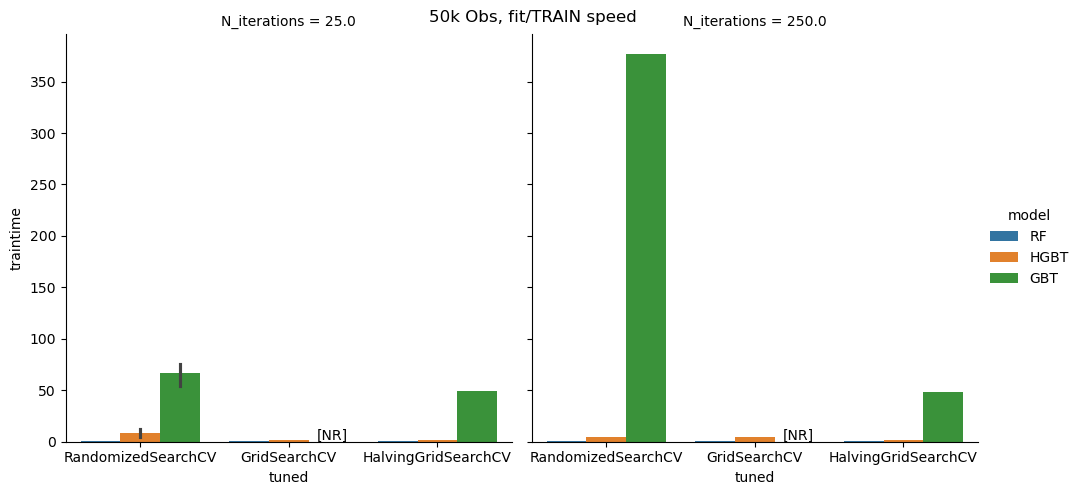

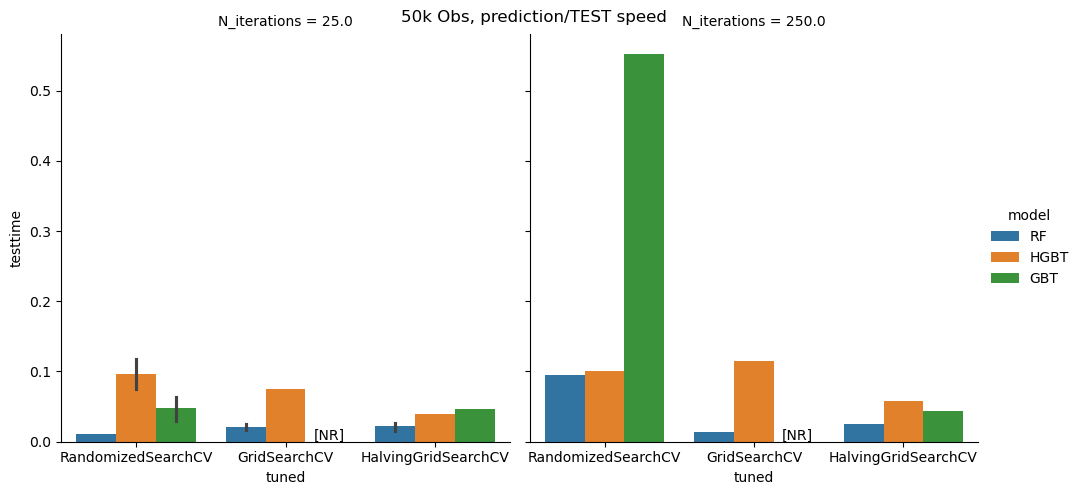

In [149]:
g = sns.catplot(data=models_50k, x="tuned", y="traintime", hue="model", kind="bar", col="N_iterations", estimator="mean", errorbar=('ci', 95),)
g.fig.suptitle("50k Obs, fit/TRAIN speed")
ax1 = g.axes.flat[0]
ax2 = g.axes.flat[1]
ax1.annotate("[NR]", xy=("GridSearchCV", 0), xycoords='data', xytext=(2, 0.1), textcoords='offset fontsize')
ax2.annotate("[NR]", xy=("GridSearchCV", 0), xycoords='data', xytext=(2, 0.1), textcoords='offset fontsize')

g = sns.catplot(data=models_50k, x="tuned", y="testtime", hue="model", kind="bar", col="N_iterations", estimator="mean", errorbar=('ci', 95),)
g.fig.suptitle("50k Obs, prediction/TEST speed")
ax1 = g.axes.flat[0]
ax2 = g.axes.flat[1]
ax1.annotate("[NR]", xy=("GridSearchCV", 0), xycoords='data', xytext=(2, 0.1), textcoords='offset fontsize')
ax2.annotate("[NR]", xy=("GridSearchCV", 0), xycoords='data', xytext=(2, 0.1), textcoords='offset fontsize')

Text(2, 0.1, '[NR]')

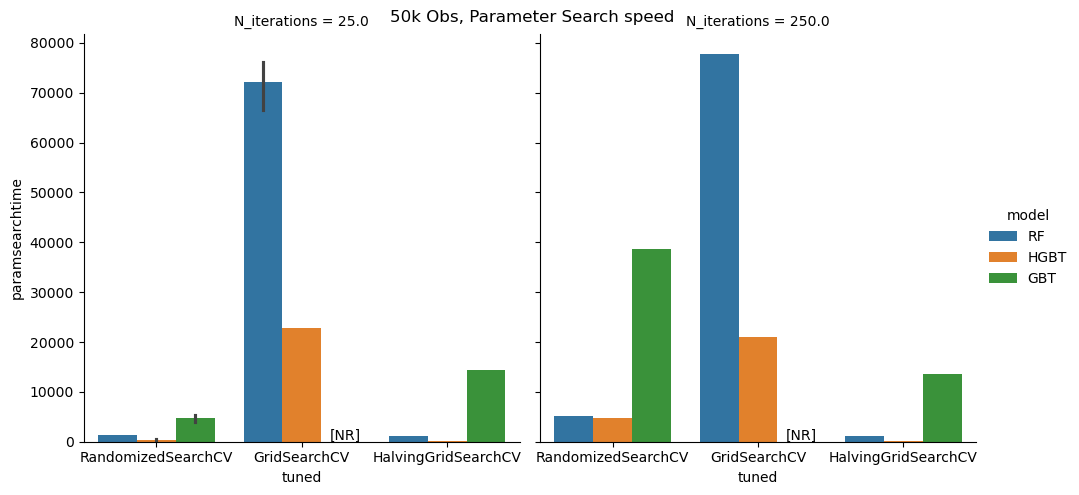

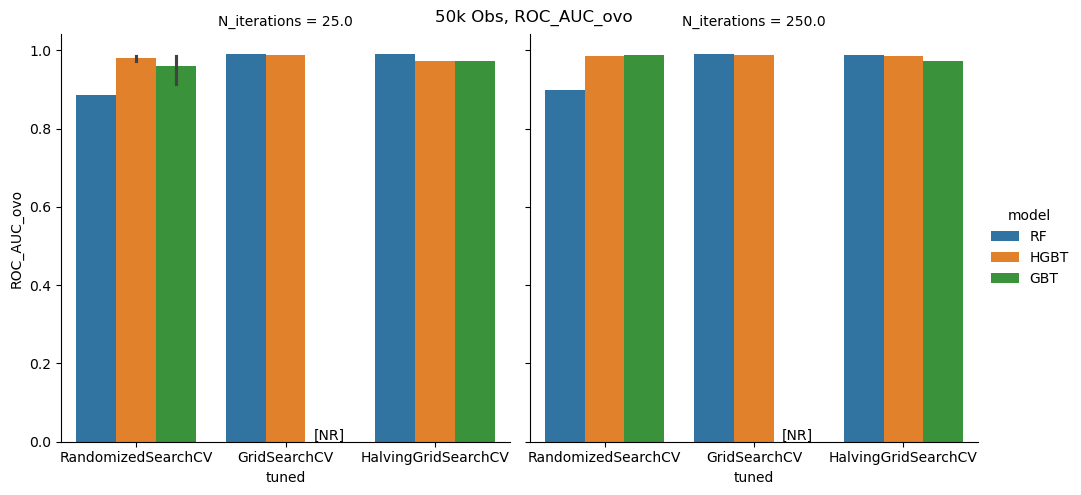

In [150]:
# ML Tuning evaluation Dataset is: Set1

g = sns.catplot(data=models_50k, x="tuned", y="paramsearchtime", hue="model", kind="bar", col="N_iterations", estimator="mean", errorbar=('ci', 95),)
g.fig.suptitle("50k Obs, Parameter Search speed")
ax1 = g.axes.flat[0]
ax2 = g.axes.flat[1]
ax1.annotate("[NR]", xy=("GridSearchCV", 0), xycoords='data', xytext=(2, 0.1), textcoords='offset fontsize')
ax2.annotate("[NR]", xy=("GridSearchCV", 0), xycoords='data', xytext=(2, 0.1), textcoords='offset fontsize')

g = sns.catplot(data=models_50k, x="tuned", y="ROC_AUC_ovo", hue="model", kind="bar", col="N_iterations", estimator="mean", errorbar=('ci', 95),)
g.fig.suptitle("50k Obs, ROC_AUC_ovo")
ax1 = g.axes.flat[0]
ax2 = g.axes.flat[1]
ax1.annotate("[NR]", xy=("GridSearchCV", 0), xycoords='data', xytext=(2, 0.1), textcoords='offset fontsize')
ax2.annotate("[NR]", xy=("GridSearchCV", 0), xycoords='data', xytext=(2, 0.1), textcoords='offset fontsize')

Text(2, 0.1, '[NR]')

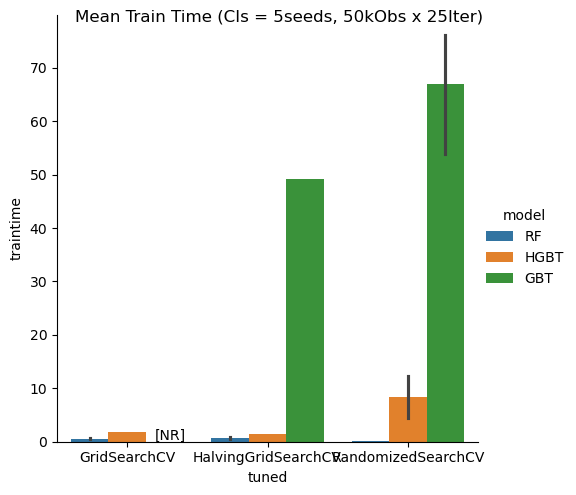

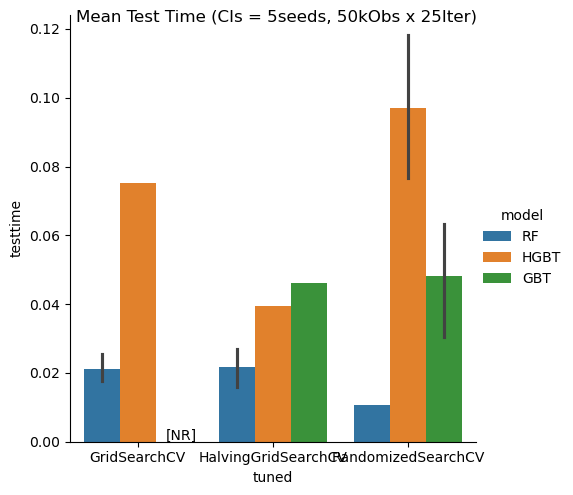

In [305]:
# ML Tuning evaluation Dataset is: Set1

g = sns.catplot(data=models_50k.query("N_iterations == 25"), x="tuned", y="traintime", hue="model", kind="bar", estimator="mean", errorbar=('ci', 95),)
g.fig.suptitle("Mean Train Time (CIs = 5seeds, 50kObs x 25Iter)")
ax1 = g.axes.flat[0]
#ax2 = g.axes.flat[1]
ax1.annotate("[NR]", xy=("GridSearchCV", 0), xycoords='data', xytext=(2, 0.1), textcoords='offset fontsize')
#ax2.annotate("[NR]", xy=("GridSearchCV", 0), xycoords='data', xytext=(2, 0.1), textcoords='offset fontsize')

g = sns.catplot(data=models_50k.query("N_iterations == 25"), x="tuned", y="testtime", hue="model", kind="bar", estimator="mean", errorbar=('ci', 95),)
g.fig.suptitle("Mean Test Time (CIs = 5seeds, 50kObs x 25Iter)")
ax1 = g.axes.flat[0]
#ax2 = g.axes.flat[1]
ax1.annotate("[NR]", xy=("GridSearchCV", 0), xycoords='data', xytext=(2, 0.1), textcoords='offset fontsize')
#ax2.annotate("[NR]", 

Text(2, 0.1, '[NR]')

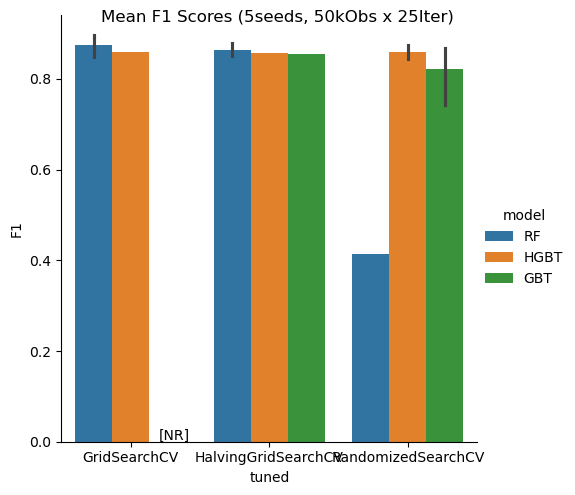

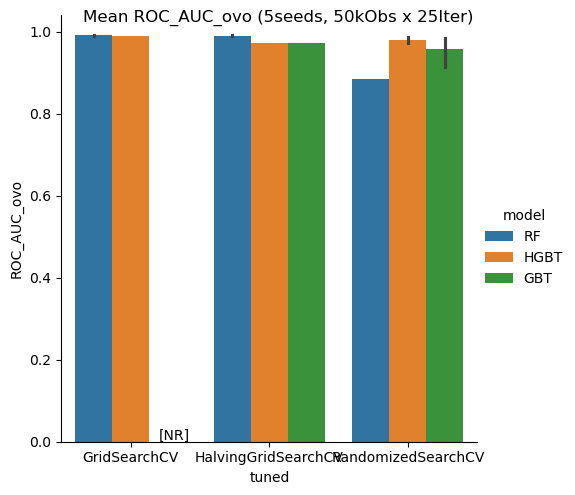

In [273]:
# ML Tuning evaluation Dataset is: Set1

g = sns.catplot(data=models_50k.query("N_iterations == 25"), x="tuned", y="F1", hue="model", kind="bar", estimator="mean", errorbar=('ci', 95),)
g.fig.suptitle("Mean F1 Scores (5seeds, 50kObs x 25Iter)")
ax1 = g.axes.flat[0]
#ax2 = g.axes.flat[1]
ax1.annotate("[NR]", xy=("GridSearchCV", 0), xycoords='data', xytext=(2, 0.1), textcoords='offset fontsize')
#ax2.annotate("[NR]", xy=("GridSearchCV", 0), xycoords='data', xytext=(2, 0.1), textcoords='offset fontsize')

g = sns.catplot(data=models_50k.query("N_iterations == 25"), x="tuned", y="ROC_AUC_ovo", hue="model", kind="bar", estimator="mean", errorbar=('ci', 95),)
g.fig.suptitle("Mean ROC_AUC_ovo (5seeds, 50kObs x 25Iter)")
ax1 = g.axes.flat[0]
#ax2 = g.axes.flat[1]
ax1.annotate("[NR]", xy=("GridSearchCV", 0), xycoords='data', xytext=(2, 0.1), textcoords='offset fontsize')
#ax2.annotate("[NR]", xy=("GridSearchCV", 0), xycoords='data', xytext=(2, 0.1), textcoords='offset fontsize')

In [282]:
models_50k.query("N_iterations == 25").groupby(["model", "tuned"]).describe()

run_ID                                        \
                           count           mean           std      min   
model tuned                                                              
GBT   HalvingGridSearchCV    1.0   86460.000000           NaN  86460.0   
      RandomizedSearchCV     6.0  112382.166667  14462.290308  83074.0   
HGBT  GridSearchCV           1.0   70820.000000           NaN  70820.0   
      HalvingGridSearchCV    1.0   70142.000000           NaN  70142.0   
      RandomizedSearchCV     6.0  113624.166667  22214.014229  68280.0   
RF    GridSearchCV           5.0  102136.000000  34070.967773  41188.0   
      HalvingGridSearchCV    6.0  104771.666667  30864.387256  41770.0   
      RandomizedSearchCV     1.0   68434.000000           NaN  68434.0   

                                                                  N_Obs  \
                                25%       50%       75%       max count   
model tuned                                                               
GBT   HalvingGridSearchCV   86460.0   86460.0   86460.0   86460.0   1.0   
      RandomizedSearchCV   117377.0  117377.0  117377.0  121711.0   6.0   
HGBT  GridSearchCV          70820.0   70820.0   70820.0   70820.0   1.0   
      HalvingGridSearchCV   70142.0   70142.0   70142.0   70142.0   1.0   
      RandomizedSearchCV   122693.0  122693.0  122693.0  122693.0   6.0   
RF    GridSearchCV         117373.0  117373.0  117373.0  117373.0   5.0   
      HalvingGridSearchCV  117372.0  117372.0  117372.0  117372.0   6.0   
      RandomizedSearchCV    68434.0   68434.0   68434.0   68434.0   1.0   

                                    ... random_seed       out_of_bag_error  \
                              mean  ...         75%   max            count   
model tuned                         ...                                      
GBT   HalvingGridSearchCV  50000.0  ...       69.00  69.0              0.0   
      RandomizedSearchCV   50000.0  ...       72.75  88.0              0.0   
HGBT  GridSearchCV         50000.0  ...       69.00  69.0              0.0   
      HalvingGridSearchCV  50000.0  ...       69.00  69.0              0.0   
      RandomizedSearchCV   50000.0  ...       72.75  88.0              0.0   
RF    GridSearchCV         50000.0  ...       69.00  74.0              4.0   
      HalvingGridSearchCV  50000.0  ...       72.75  88.0              5.0   
      RandomizedSearchCV   50000.0  ...       69.00  69.0              0.0   

                                                                          \
                              mean       std      min       25%      50%   
model tuned                                                                
GBT   HalvingGridSearchCV      NaN       NaN      NaN       NaN      NaN   
      RandomizedSearchCV       NaN       NaN      NaN       NaN      NaN   
HGBT  GridSearchCV             NaN       NaN      NaN       NaN      NaN   
      HalvingGridSearchCV      NaN       NaN      NaN       NaN      NaN   
      RandomizedSearchCV       NaN       NaN      NaN       NaN      NaN   
RF    GridSearchCV         0.00778  0.000319  0.00741  0.007575  0.00780   
      HalvingGridSearchCV  0.00808  0.000291  0.00768  0.007870  0.00821   
      RandomizedSearchCV       NaN       NaN      NaN       NaN      NaN   

                                              
                                75%      max  
model tuned                                   
GBT   HalvingGridSearchCV       NaN      NaN  
      RandomizedSearchCV        NaN      NaN  
HGBT  GridSearchCV              NaN      NaN  
      HalvingGridSearchCV       NaN      NaN  
      RandomizedSearchCV        NaN      NaN  
RF    GridSearchCV         0.008005  0.00811  
      HalvingGridSearchCV  0.008290  0.00835  
      RandomizedSearchCV        NaN      NaN  

[8 rows x 96 columns]

In [314]:
repeated_means = models_50k.query("N_iterations == 25").groupby(["model", "tuned"])[["F1", "ROC_AUC_ovo", "accuracy", "testtime", "traintime"]].mean()
repeated_means

F1  ROC_AUC_ovo  accuracy  testtime  \
model tuned                                                            
GBT   HalvingGridSearchCV  0.854940     0.973420  0.987840  0.046210   
      RandomizedSearchCV   0.822702     0.958745  0.988440  0.048260   
HGBT  GridSearchCV         0.858170     0.988190  0.990720  0.075080   
      HalvingGridSearchCV  0.856300     0.971260  0.991840  0.039380   
      RandomizedSearchCV   0.859900     0.980073  0.991013  0.096953   
RF    GridSearchCV         0.875532     0.990622  0.992096  0.021152   
      HalvingGridSearchCV  0.864553     0.989833  0.991640  0.021767   
      RandomizedSearchCV   0.414320     0.884900  0.972560  0.010650   

                           traintime  
model tuned                           
GBT   HalvingGridSearchCV  49.185440  
      RandomizedSearchCV   67.048468  
HGBT  GridSearchCV          1.790720  
      HalvingGridSearchCV   1.450290  
      RandomizedSearchCV    8.306882  
RF    GridSearchCV          0.567329  
      HalvingGridSearchCV   0.648276  
      RandomizedSearchCV    0.228700

In [317]:
repeated_means.style.background_gradient(
    axis=0, # column-wise
    vmin=0.0, 
    vmax=2, 
    subset=["traintime"],
    cmap=sns.color_palette("mako", as_cmap=True)
) # apply colouring column-wise

In [313]:
repeated_means.style.background_gradient(
    axis=0, # column-wise
    vmin=0.0, 
    vmax=0.04, 
    subset=["testtime"],
    cmap=sns.color_palette("mako", as_cmap=True)
) # apply colouring column-wise

The fastest test/predict time was returned by RF Randomized, however this is not a repeated result and could vary if repeated.

The second fastest prediction time was RF GridSearch, and third was RF HalvingGrid, with all of these models coming from the Random Forest stable. Both of these combinations have at least 5 runs averaged to comprise these reported results and are reliable. 

In [309]:
repeated_means.style.background_gradient(
    axis=0, # column-wise
    vmin=0.991, 
    vmax=repeated_means["accuracy"].max(), 
    subset=["accuracy"],
    cmap=sns.color_palette("mako_r", as_cmap=True)
) # apply colouring column-wise

RF GridSearch has highest accuracy, followed by RF HalvingGrid and HGBT HalvingGrid.

In [269]:
repeated_means.style.background_gradient(
    axis=0, # column-wise
    vmin=0.855, 
    vmax=repeated_means["F1"].max(), 
    subset=["F1"],
    cmap=sns.color_palette("mako_r", as_cmap=True) # viridis colour-map
    #cmap=sns.cubehelix_palette(start=2, rot=0, dark=0, light=.95, reverse=False, as_cmap=True)
) # apply colouring column-wise)


RF GridSearch has highest F1, followed by RF HalvingGrid and then HGBT Randomized

In [270]:
repeated_means.style.background_gradient(
    axis=0, # column-wise
    vmin=0.97, 
    vmax=repeated_means["ROC_AUC_ovo"].max(), 
    subset=["ROC_AUC_ovo"],
    cmap=sns.color_palette("mako_r", as_cmap=True) # viridis colour-map
) # apply colouring column-wise

RF GridSearch has highest ROC AUC, followed by RF HalvingGrid and then HGBT Grid

In [302]:
def highlight(s):
    if s.N_Obs >= 5:
        return ['background-color: yellow'] * len(s)
    else:
        return ['background-color: white'] * len(s)

In [303]:
repeats_Nreps = models_50k.query("N_iterations == 25").groupby(["model", "tuned"]).count()["N_Obs"].reset_index()
repeats_Nreps.style.apply(highlight, axis=1) # colour rows matching "greater than" thresholds

,model,tuned,N_Obs
0,GBT,HalvingGridSearchCV,1
1,GBT,RandomizedSearchCV,6
2,HGBT,GridSearchCV,1
3,HGBT,HalvingGridSearchCV,1
4,HGBT,RandomizedSearchCV,6
5,RF,GridSearchCV,5
6,RF,HalvingGridSearchCV,6
7,RF,RandomizedSearchCV,1


Not all combinations of model and tuning have been run with repeats, as this was prioritised for the top 5 performing combinations in terms of ROC_AUC_ovo\*: a score which computes average Reciever Operating Characteristic (ROC) Area Under the Curve (AUC) with the average of all possible pairwise combinations of classes. 

NOTE: Still awaiting Repetition results for HGBT x GridSearch combination. 
NOTE: Where N_Obs here shows 6 runs, two of these runs use the same random seed.

(\* = ROC_AUC_ovo: insensitive to class imbalance and did not take label imbalance into account as average='macro' during calculation.)

### Summary of (selected) Repeated Tuning Comparisons: 
(Set1 dataset, 50,000 Observations, 25 iterations; with training:test split of 75:25; cross validation of 5 splits, 10 repeats)


**RF GridSearch gives THE BEST results in terms of average ROC_AUC_ovo score, F1 and accuracy score.** The means are derived from 5 runs. 

*The next best average results are obtained by RF HalvingGrid.* These means are derived from 6 runs, however two of these runs use the same random seed.

However for the third best average results, there's no variation amongst models (HGBTx3) but all tuning methods (Halving, Randomized and Grid) have received a 'third' place, so *no clear bronze medallist.* 
Amongst these contenders, if pressed, we might consider ROC_AUC_ovo our tie-breaker variable as a measure of good performance without overfitting, therefore potentially award the bronze to HGBT Grid, however this result currently has only ONE seed run, so this is not a calculated mean but a raw result value from a single run. 
This combo (HGBT Grid) is in the queue for repeat seed runs so is worth waiting for these results to be confirmed.

NOTE: 100pc Set2 run took ~191 mins, but was run after VM expansion so may not be comparable.


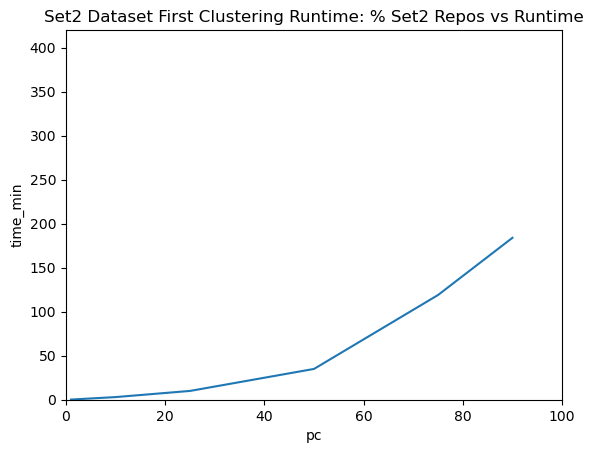

In [138]:
set2runtimes = {"pc": [1, 10, 25, 50, 75, 90,  100], "time_min": [0.2, 3, 10, 35, 119, 184, None,]}
set2runtimes_df = pd.DataFrame(data=set2runtimes)
set2runtimes_df

ax = sns.lineplot(data=set2runtimes_df, x="pc", y="time_min", )
ax.set(xlim=(0, 100)) # 100 pc of dataset max
ax.set(ylim=(0, 420)) # Over 7 hours max
ax.set_title("""Set2 Dataset First Clustering Runtime: % Set2 Repos vs Runtime""")
print("NOTE: 100pc Set2 run took ~191 mins, but was run after VM expansion so may not be comparable.")

Issues: 

admin/#229 
admin/#230

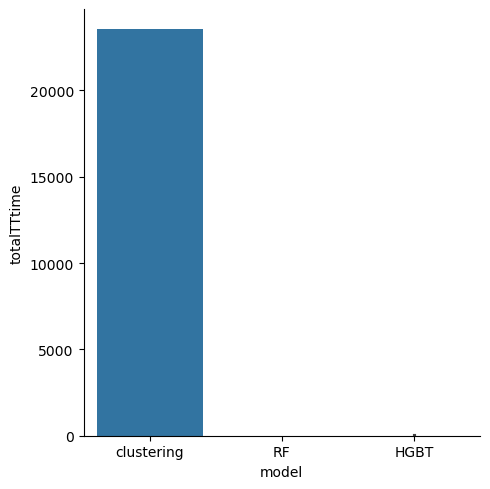

In [66]:
sns.catplot(data=models_df, x="model", y="totalTTtime", hue="model", kind="bar", log_scale=False,) 
# this is unhelpful D:
# could maybe add the values on above the bars, so that there's SOMETHING for RF?

In [ ]:
models_df.iloc[1:,:]

ValueError: cannot reindex on an axis with duplicate labels

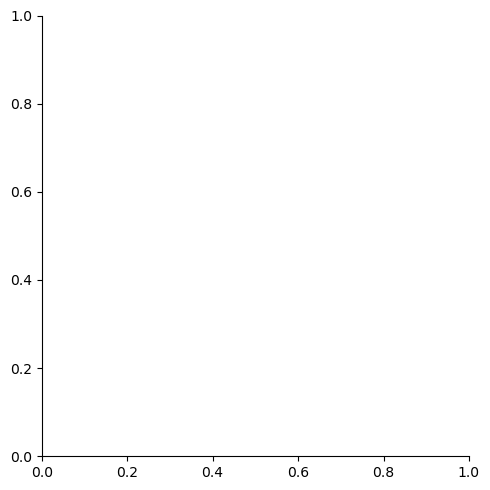

In [13]:
sns.catplot(data=models_df, x="tuned", y="totalTTtime", hue="tuned", kind="bar", log_scale=False) 
print("total run time (excl hyper-param search) values for RF")

Accuracy values for RF


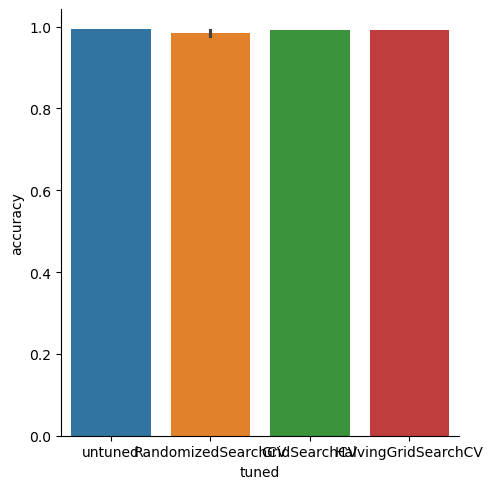

In [89]:
sns.catplot(data=models_df.iloc[1:,:], x="tuned", y="accuracy", hue="tuned", kind="bar", log_scale=False,) 
print("Accuracy values for RF")

F1 values for RF


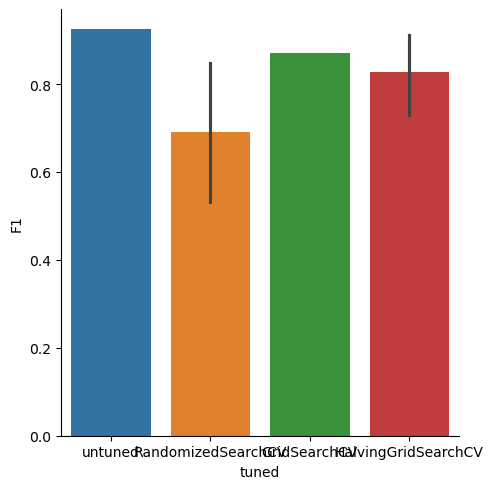

In [90]:
sns.catplot(data=models_df.iloc[1:,:], x="tuned", y="F1", hue="tuned", kind="bar", log_scale=False,) 
print("F1 values for RF")

ValueError: cannot reindex on an axis with duplicate labels

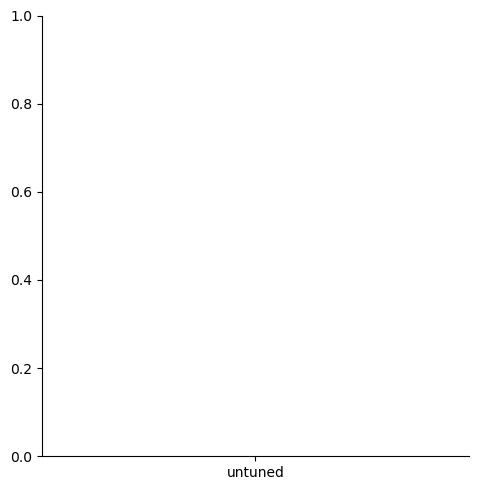

In [129]:
#sns.catplot(data=models_df, x="tuned", y="ROC_AUC_ovo", hue="model", kind="bar", log_scale=False,) 
#print("ROC_AUC_ovo for RF")

ROC_AUC for RF, 50k Obs, 250 Iterations


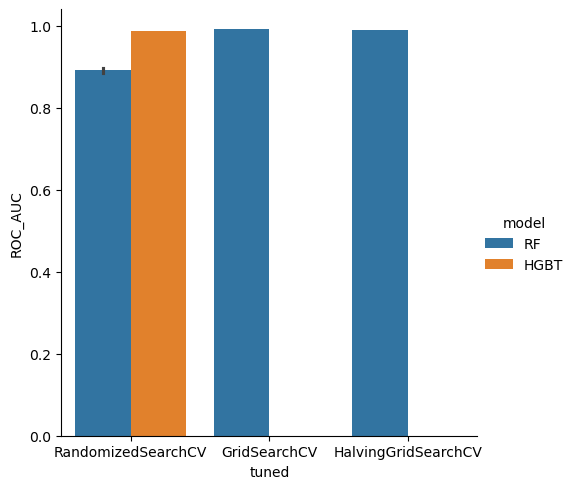

In [92]:
sns.catplot(data=models_50k_250it, x="tuned", y="ROC_AUC_ovo", hue="model", kind="bar", log_scale=False,) 
print("ROC_AUC for RF, 50k Obs, 250 Iterations")

N of Observations used for test/train split for RF


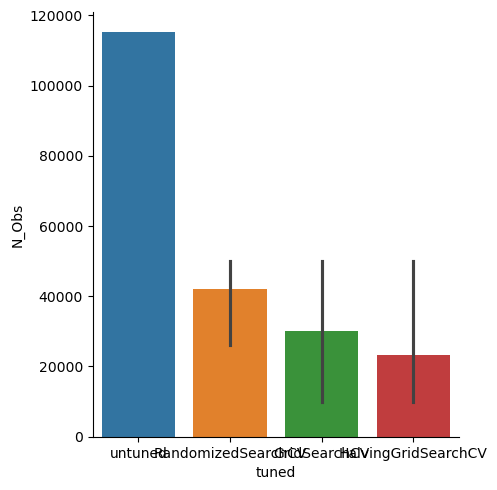

In [93]:
#sns.catplot(data=models_df, x="tuned", y="N_Obs", hue="tuned", kind="bar", log_scale=False,) 
#print("N of Observations used for test/train split for RF")

In [16]:
pd.read_csv("../../data/RF_paramsearch_N2500_2026-02-14.csv")

,iter,n_resources,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_ccp_alpha,param_criterion,param_max_depth,param_max_features,...,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,split3_train_score,split4_train_score,mean_train_score,std_train_score
0,0,70,0.154573,0.017711,0.025764,0.006611,0.000,gini,10.0,2.0,...,0.480912,0.268130,7669,0.486239,0.481481,0.486239,0.320988,0.490909,0.453171,0.066159
1,0,70,0.232230,0.020514,0.028423,0.003365,0.000,gini,10.0,2.0,...,0.480912,0.268130,7669,0.486239,0.481481,0.486239,0.320988,0.490909,0.453171,0.066159
2,0,70,0.293513,0.023526,0.034928,0.004028,0.000,gini,10.0,2.0,...,0.480912,0.268130,7669,0.486239,0.481481,0.486239,0.320988,0.490909,0.453171,0.066159
3,0,70,0.368439,0.018571,0.034851,0.007463,0.000,gini,10.0,2.0,...,0.480912,0.268130,7669,0.486239,0.481481,0.486239,0.320988,0.490909,0.453171,0.066159
4,0,70,0.170279,0.009303,0.019161,0.001824,0.000,gini,10.0,2.0,...,0.480912,0.268130,7669,0.486239,0.481481,0.486239,0.320988,0.490909,0.453171,0.066159
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13763,4,5670,0.538468,0.028411,0.076480,0.019607,0.000,gini,10.0,NaN,...,0.697009,0.036474,201,0.920617,0.882715,0.862821,0.920622,0.880319,0.893419,0.023247
13764,4,5670,0.569395,0.033803,0.077356,0.033437,0.005,log_loss,10.0,NaN,...,0.700144,0.044145,178,0.734745,0.782456,0.759039,0.779582,0.786267,0.768418,0.019298
13765,4,5670,0.616945,0.024361,0.073280,0.026640,0.000,log_loss,35.0,4.0,...,0.710852,0.045961,131,0.939486,0.928279,0.807408,0.808952,0.881481,0.873121,0.056485
13766,4,5670,0.606215,0.053452,0.059882,0.020057,0.005,log_loss,35.0,NaN,...,0.725753,0.038842,93,0.755484,0.748198,0.754470,0.787138,0.783300,0.765718,0.016163


In [17]:
pd.read_csv("../../data/test_prediction_data_N2500_2026-02-14.csv")

,Test true,Test predicted
0,1,1
1,1,1
2,1,1
3,1,1
4,5,5
...,...,...
2495,1,1
2496,1,1
2497,1,1
2498,1,1


In [ ]:
##### THIS IS THE SCRIPT CODE BEING RUN; DECISION TREE SHENANIGANS BELOW:

In [ ]:
#from githubanalysis.analysis.baby_ML_pipeline import ML_Pipeline_Decision_Tree, main
main(
    dataset_name="ML",
    in_notebook=True,
    exists_ok=True,
    logger=None,
    datafile="sample_45pc_all_subclusters_named_personas_dataset_2025-09-16.csv",
    small_vers=True,
    small_N_appx=50,
    train_pc=0.75,
    test_pc=0.25,
    shuffle_state=True,
    stratify_state=True, # ensuring all personas present in test and training in ~natural ratio
)

[Pipeline] ............... (step 1 of 1) Processing clf, total=   0.4s
attempted to save out to : ../../images/analysis_run_ML_2026-02-02/decision_tree_initial.pdf


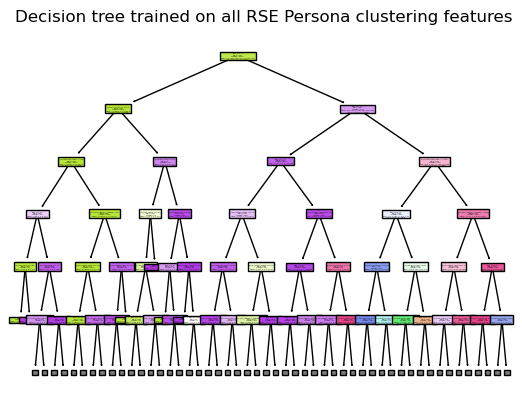

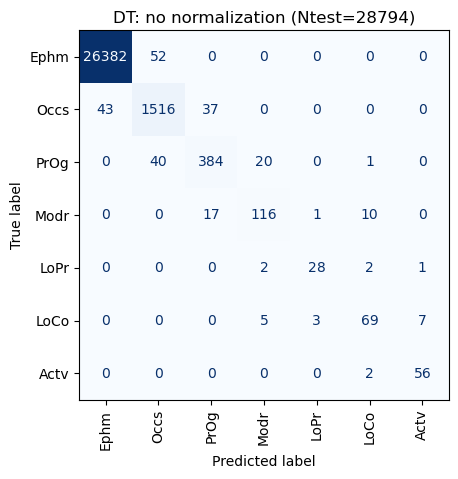

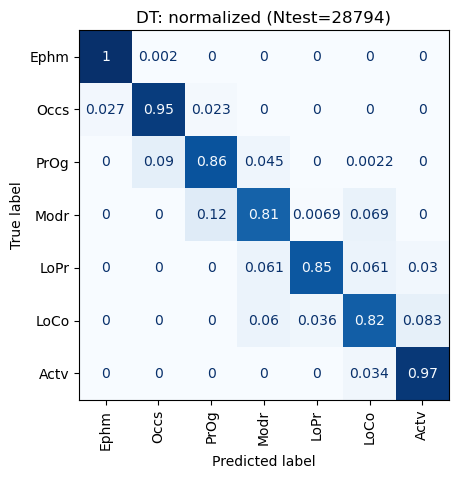


            For decision_tree model trained on: 

            datafile: ../../data/sample_45pc_all_subclusters_named_personas_dataset_2025-09-16.csv 

            training-set size: N=86380 

            and evaluated using test-set size: N=28794 repo-individuals 

            using N=10 features 
 
            at 2026-02-02 

            TRAIN (fit) TIME: 0.3631420135498047 seconds 

            TEST (predict) TIME: 0.005074024200439453 seconds 

            with parameters: {'memory': None, 'steps': [('clf', DecisionTreeClassifier(random_state=42))], 'verbose': True}
            
Accuracy: 0.99156 (percent of correctly classified samples)
Non-Normalised Accuracy: 28551 (number of correctly classified samples)
Balanced Accuracy: 0.89312 (the average of recall obtained on each class)
F1 Score: 0.88909 (harmonic mean of the precision and recall, both equally weighted)
Precision: 0.88578 (Ratio of correctly predicted positive classes to total of positive predictions)
Recall: 0.89312 (Ra

[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    8.2s finished


[Pipeline] ............... (step 1 of 1) Processing clf, total=   8.8s


[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    0.2s finished


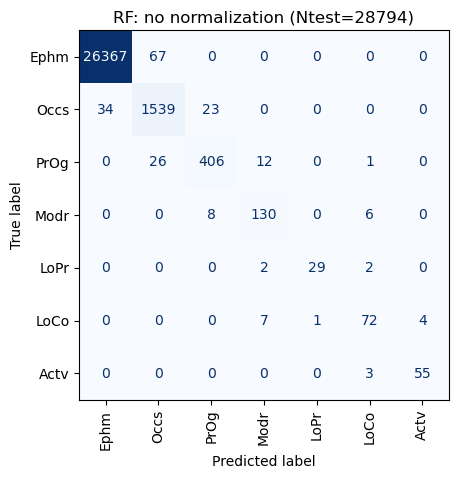

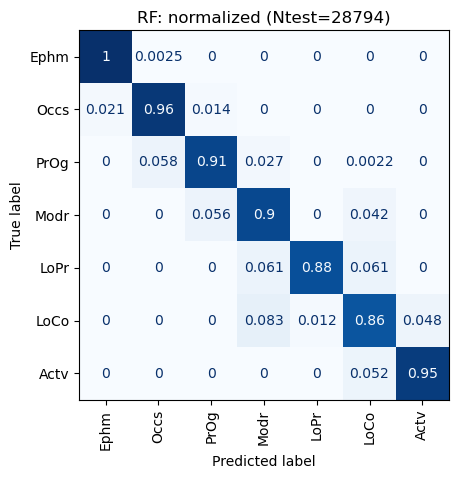


            For random_forest model trained on: 

            datafile: ../../data/sample_45pc_all_subclusters_named_personas_dataset_2025-09-16.csv 

            training-set size: N=86380 

            and evaluated using test-set size: N=28794 repo-individuals 

            using N=10 features 
 
            with N=100 trees in forest  

            at 2026-02-02 
 
            TRAIN (fit) TIME: 8.78955888748169 seconds 

            TEST (predict) TIME: 0.18402099609375 seconds 

            with parameters: {'memory': None, 'steps': [('clf', RandomForestClassifier(max_features=3, oob_score=True, random_state=42,
                       verbose=1))], 'verbose': True}
        
Accuracy: 0.99319 (percent of correctly classified samples)
Non-Normalised Accuracy: 28598 (number of correctly classified samples)
Balanced Accuracy: 0.92301 (the average of recall obtained on each class)
F1 Score: 0.92451 (harmonic mean of the precision and recall, both equally weighted)
Precision: 0.92682 (

[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    0.2s finished


Area Under the Receiver Operating Characteristic Curve (ROC AUC): 0.99981
Out of Bag Error: 0.00644
Classification Report: 
                         precision    recall  f1-score   support

    Active Contributor      0.932     0.948     0.940        58
 Ephemeral Contributor      0.999     0.997     0.998     26434
     Low-Coding Closer      0.857     0.857     0.857        84
    Low-Process Closer      0.967     0.879     0.921        33
  Moderate Contributor      0.861     0.903     0.881       144
Occasional Contributor      0.943     0.964     0.954      1596
     Project Organiser      0.929     0.912     0.921       445

              accuracy                          0.993     28794
             macro avg      0.927     0.923     0.925     28794
          weighted avg      0.993     0.993     0.993     28794

Binning 0.007 GB of training data: 0.096 s
Fitting gradient boosted rounds:
[1/100] 7 trees, 482 leaves (68 on avg), max depth = 16, in 0.086s
[2/100] 7 trees, 1854 lea

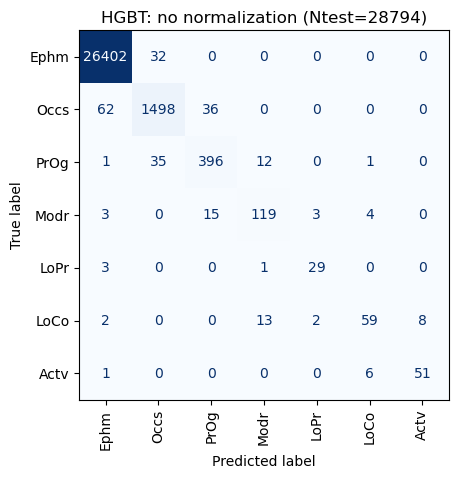

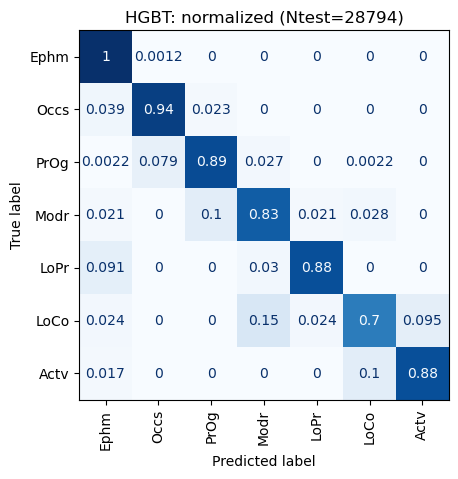


            For hist_gradient_boosting model trained on: 

            datafile: ../../data/sample_45pc_all_subclusters_named_personas_dataset_2025-09-16.csv 

            training-set size: N=86380 

            and evaluated using test-set size: N=28794 repo-individuals 

            using N=10 features 
 
            at 2026-02-02 

            TRAIN (fit) TIME: 29.276313066482544 seconds 

            TEST (predict) TIME: 0.4810316562652588 seconds 

            with parameters: {'memory': None, 'steps': [('clf', HistGradientBoostingClassifier(early_stopping=False, l2_regularization=0,
                               learning_rate=0.01, max_leaf_nodes=None,
                               random_state=42, verbose=1))], 'verbose': True}
            
Accuracy: 0.99166 (percent of correctly classified samples)
Non-Normalised Accuracy: 28554 (number of correctly classified samples)
Balanced Accuracy: 0.87345 (the average of recall obtained on each class)
F1 Score: 0.88014 (harmonic mean

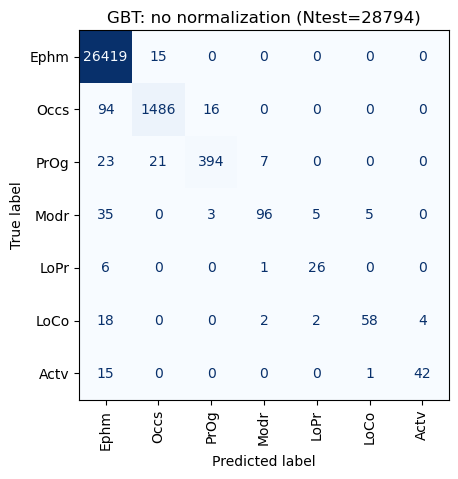

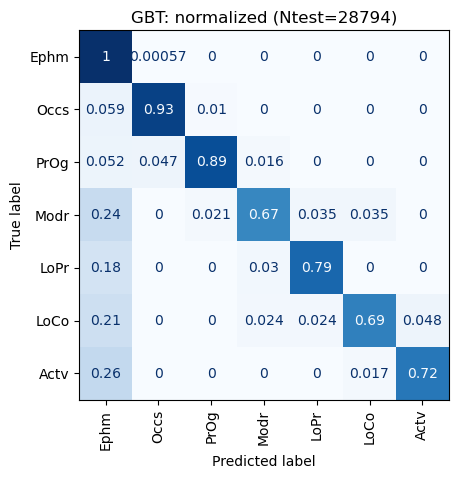


            For gradient_boosting model trained on: 

            datafile: ../../data/sample_45pc_all_subclusters_named_personas_dataset_2025-09-16.csv 

            training-set size: N=86380 

            and evaluated using test-set size: N=28794 repo-individuals 

            using N=10 features 
 
            at 2026-02-02 

            TRAIN (fit) TIME: 143.66232228279114 seconds 

            TEST (predict) TIME: 0.6406552791595459 seconds 

            with parameters: {'memory': None, 'steps': [('clf', GradientBoostingClassifier(learning_rate=0.01, max_depth=None, max_features=3,
                           random_state=42))], 'verbose': True}
            
Accuracy: 0.99052 (percent of correctly classified samples)
Non-Normalised Accuracy: 28521 (number of correctly classified samples)
Balanced Accuracy: 0.81215 (the average of recall obtained on each class)
F1 Score: 0.85929 (harmonic mean of the precision and recall, both equally weighted)
Precision: 0.91943 (Ratio of corre

In [3]:
#from githubanalysis.analysis.baby_ML_pipeline import ML_Pipeline_Decision_Tree, main
main(
    dataset_name="ML",
    in_notebook=True,
    exists_ok=True,
    logger=None,
    datafile="sample_45pc_all_subclusters_named_personas_dataset_2025-09-16.csv",
    small_vers=False,
    small_N_appx=None,
    train_pc=0.75,
    test_pc=0.25,
    shuffle_state=True,
    stratify_state=True, # ensuring all personas present in test and training in ~natural ratio
)

In [4]:
from datetime import datetime

#FMT = '%Y-%m-%d %H:%M:%S.%f'
init_start = "2025-05-12 23:48:29,432"
init_end= "2025-05-13 02:50:10,882"
        
init_time = datetime.fromisoformat(init_end.replace(',', '.')) - datetime.fromisoformat(init_start.replace(',', '.'))
init_time

cl0_start = "2025-05-13 12:54:19,291"
cl0_end = "2025-05-13 12:54:24,940"
cl0_time = datetime.fromisoformat(cl0_end.replace(',', '.')) - datetime.fromisoformat(cl0_start.replace(',', '.'))

cl1_start = "2025-05-13 12:53:55,309"
cl1_end = "2025-05-13 12:53:59,770"
cl1_time = datetime.fromisoformat(cl1_end.replace(',', '.')) - datetime.fromisoformat(cl1_start.replace(',', '.'))

cl2_start = "2025-05-13 07:30:19,998"
cl2_end = "2025-05-13 11:00:39,965"
cl2_time = datetime.fromisoformat(cl2_end.replace(',', '.')) - datetime.fromisoformat(cl2_start.replace(',', '.'))

overall_time = init_time + cl0_time + cl1_time + cl2_time
print(f"{overall_time.total_seconds()} seconds total")

print(f"{overall_time.total_seconds()/60} minutes total")
print(f"{overall_time.total_seconds()/60/60} hours total")


print(f"8.97s is {overall_time.total_seconds()/8.97} times faster than clustering...")

23531.527 seconds total
392.19211666666666 minutes total
6.536535277777777 hours total
8.97s is 2623.3586399108135 times faster than clustering...


In [5]:
        self.y_pred = self.pipe.predict(X_test)
        self.y_true = y_test

        # savefig kwargs
        saveout_args = dict(
            dpi=400,
            format="pdf",
            bbox_inches="tight",
        )

        # Plot non-normalized confusion matrix
        titles_options = [
            (
                f"{self.model_type} CM, no normalization (N={self.X_test_size[0]})",
                None,
            ),
            (
                f"{self.model_type} normalized CM (N={self.X_test_size[0]})",
                "true",
            ),  # normalise on True value pcs
        ]

        persona_order = [
            "Ephemeral Contributor",
            "Occasional Contributor",
            "Project Organiser",
            "Moderate Contributor",
            "Low-Process Closer",
            "Low-Coding Closer",
            "Active Contributor",
        ]

        for title, normalize in titles_options:
            disp = ConfusionMatrixDisplay.from_predictions(
                self.le.inverse_transform(self.y_true),  # y_true
                self.le.inverse_transform(self.y_pred),  # y_pred
                labels=persona_order,  # personas listed in increasing MRC order
                sample_weight=None,
                normalize=normalize,  # 'all': total N samples; 'pred': over predictions; 'true': over true; None: default
                display_labels=None,
                include_values=True,
                xticks_rotation="vertical",
                values_format=None,
                cmap=cmx.Blues,
                ax=None,
                colorbar=False,
                im_kw=None,
                text_kw=None,
            )
            disp.ax_.set_title(title)
            saveout_name = Path(
                self.image_write_location,
                f"{self.model_type}_confusion_matrix_normalise{normalize}_N{self.X_test_size[0]}_{self.current_date_info}.pdf",
            )
            plt.savefig(
                saveout_name,
                **saveout_args,
            )
            plt.show()


NameError: name 'self' is not defined

In [ ]:
# # DECISION-TREE
# # 150k dataset of repo-individuals (Set1/45pc)

# # run as single function: 
# main(
#     dataset_name="ML",
#     in_notebook=True,
#     exists_ok=True,
#     logger=None,
#     datafile="../../data/sample_45pc_all_subclusters_named_personas_dataset_2025-09-16.csv",
#     small_vers=False,
#     small_N_appx=None,
#     train_pc=0.75,
#     test_pc=0.25,
#     shuffle_state=True,
#     stratify_state=True, # ensuring all personas present in test and training in ~natural ratio
# )

In [ ]:
# # DECISION-TREE
# # small (per-persona-sampled) dataset as 'whole sample', aiming for ~50ish records 

# #proto-code for pipeline, pulled into main() run as single function: 

# ml_pipeline_dt = ML_pipeline_decision_tree(dataset_name="ML", in_notebook=True, exists_ok=True, logger=None)

# # create a pipeline object
# pipe = Pipeline(steps=[ # diff twixt make_pipeline()/Pipeline(): https://stackoverflow.com/a/40708448
#     #('le', LabelEncoder()),
#     ('clf', DecisionTreeClassifier()),
# ], 
#     memory=None, 
#     #transform_input=None, # I maybe don't have the updated package version for this (1.6?)
#     verbose=True,
# )
# print(pipe.get_params())

# # load the dataset and split it into train and test sets
# # read in dataset
# datafile = Path(
#     ml_pipeline_dt.data_location,
#     "sample_45pc_all_subclusters_named_personas_dataset_2025-09-16.csv",
# )
# # small (per-persona-sampled) dataset as 'whole sample', aiming for ~50ish records 
# classified_df = ml_pipeline_dt.get_data(data_file=datafile, small_vers=True, small_N_appx=50) # 50ish REPO-INDIVIDS ONLY!
# RSE_info = ml_pipeline_dt.create_sklearn_format_data(classified_df=classified_df)

# # set X (data, no colnames, no personas), y (personas only)
# X, y = RSE_info["data"], RSE_info["target"]

# # create testing/training dataset
# X_train, X_test, y_train, y_test = train_test_split(
#                 X,
#                 y,
#                 #test_size, #=test_pc,  # by (sklearn) default if int: N of samples; if float: proportion of sample; if None and train_size=None also, it uses 25%
#                 #train_size, #=train_pc,  # by (sklearn) default if int: N of samples; if float: proportion of sample; if None and train_size=None also, it uses 75%
#                 random_state=42,
#                 shuffle=True, #shuffle_state,  # True by (sklearn) default
#                 stratify=RSE_info[
#                     "target"
#                 ],  # same as y; None by (sklearn) default
#             )

# # fit the whole pipeline
# ##########

# pipe.fit(X_train, y_train)

# # plot the decision tree
# tree.plot_tree(
#     pipe.named_steps['clf'], # use fitted pipe obj created by 'decision_tree step'
#     max_depth=5, 
#     filled=True,
#     feature_names=RSE_info["feature_names"],
#     class_names=RSE_info["target_names"],
# )

# pipe.predict(X_test)
# #pipe.le.transform(y_test)

# # savefig kwargs
# saveout_args = dict(
#     dpi=400,
#     format="pdf",
#     bbox_inches="tight",
# )
# dataset_size = len(X_test)

# # Plot non-normalized confusion matrix
# titles_options = [
#     (
#         f"confusion matrix, no normalization (N={dataset_size})",
#         None,
#     ),
#     (
#         f"normalized confusion matrix (N={dataset_size})",
#         "true",
#     ),  # normalise on True value pcs
# ]


# for title, normalize in titles_options:
#     disp = ConfusionMatrixDisplay.from_predictions(
#         #y_pred = pipe.predict(X_test),    
#         y_pred = ml_pipeline_dt.le.inverse_transform(pipe.predict(X_test)), 
#         #y_true= y_test,  
#         #self.le.inverse_transform(y_true),  # y_true
#         y_true = ml_pipeline_dt.le.inverse_transform(y_test),  # y_pred
#         labels=ml_pipeline_dt.le.inverse_transform(pipe.named_steps['clf'].classes_),
#         sample_weight=None,
#         normalize=normalize,  # 'all': total N samples; 'pred': over predictions; 'true': over true; None: default
#         display_labels=None,
#         include_values=True,
#         xticks_rotation="vertical",
#         values_format=None,
#         cmap=cmx.Blues,
#         ax=None,
#         colorbar=False,
#         im_kw=None,
#         text_kw=None,
#     )
#     disp.ax_.set_title(title)
# #     saveout_name = Path(
# #         self.image_write_location,
# #         f"confusion_matrix_MRC_tinytestset_normalise{normalize}_{self.current_date_info}.pdf",
# #     )
# #     plt.savefig(
# #         saveout_name,
# #         **saveout_args,
# #     )
#     plt.show()


# Adding noise to Training Data

In [ ]:
# in Hamza & Larocque 2005, they REPLACED 10% of the TRAINING data 'dependent variable' 
  # Q: WHAT IS MY DEPENDENT VARIABLE?!?! (? all of them? )  
# ... replaced it with a 'value chosen uniformly at random among its other possible values'.
# aka "random misclassification of the response" 
# (authors ref: to Breiman, L., 2001, Random forests. Machine Learning, 45, 5–32.)

# Steps: 

# in the TRAINING DATA
# dependent variable: is this the persona? This is LABEL FLIPPING if so...  
# BUT if I add noise to the clustering vars instead, that's more typically 'adding noise to data'

# Breiman 1998c added noise to random forest outputs also, 
# 10% noise seems fairly common? 

In [47]:
#Via: https://stackoverflow.com/a/14058425

import numpy as np

noise = np.random.normal(0,1,100)

# 0 is the mean of the normal distribution you are choosing from
# 1 is the standard deviation of the normal distribution
# 100 is the number of elements you get in array noise

In [77]:
from githubanalysis.analysis.ML_tuning import BaseTuningSetup

tuning_setup = BaseTuningSetup(
    dataset_name="ML_tune_noise",
    in_notebook=True,
    exists_ok=True,
    logger=None,
    ML_CLASS="RF",
    N_OBS=100,
    N_ITER=3,
    RANDOM_STATE=69,
    SEARCH_METHOD="RandomizedSearchCV",
    N_JOBS=1,
)


print("prepping dataset")
tuning_setup.prep_data()

print("splitting dataset")
tuning_setup.setup_test_train()

prepping dataset


INFO:(100, 10)
INFO:10
INFO:self.X_train_size = (75, 10)
INFO:self.X_test_size = (25, 10)


splitting dataset


In [78]:
tuning_setup.X_train # min=-100, max=100, mean=0.8313200149375449, std=6.396901551262343

array([[ 9.02934537e-01,  7.83289817e-01,  0.00000000e+00,
         0.00000000e+00,  3.79403794e+00,  1.19760479e+00,
         1.09605246e+00,  1.18741977e+00,  1.49355058e+00,
         7.83289817e-03],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  2.94550810e-01,  0.00000000e+00,
         5.89101620e-02,  4.15368640e-02,  7.73993808e-02,
         0.00000000e+00],
       [ 0.00000000e+00,  1.30123617e-01,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         2.60247235e-02,  1.63345312e-02,  4.25350915e-02,
         1.30123617e-03],
       [ 5.71715533e-01,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  1.26802980e+00,  0.00000000e+00,
         3.67949066e-01,  5.76996077e-01,  1.86317322e+00,
         0.00000000e+00],
       [ 0.00000000e+00,  1.22699387e-01,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         2.45398773e-02,  3.41296928e-02,  6.96378830e-02,
         1.

In [29]:
print(type(tuning_setup.X_train))
print(tuning_setup.X_train.shape)

<class 'numpy.ndarray'>
(75, 10)


In [30]:
print(tuning_setup.X_train.ndim)

2


In [31]:
tuning_setup.y_train # min: 0, max: 6

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0])

In [ ]:
#noise = np.random.normal(0,1,100)
# 0 is the mean of the normal distribution you are choosing from
# 1 is the standard deviation of the normal distribution
# 100 is the number of elements you get in array noise

In [35]:
# Generate noise with same size as that of the data.
noise = np.random.normal(
    0, #  μ (mean) = 0, 
    1, # σ (standard dev) = 2, 
    len(tuning_setup.X_train) # size = length of x or y. Choose μ and σ wisely.
) 

In [36]:
type(noise)

numpy.ndarray

In [33]:
tuning_setup.X_train.shape

(75, 10)

In [37]:
for col in range(tuning_setup.X_train.shape[1]):
    print(col)
    #print(tuning_setup.X_train[:,col][0:4])

0
1
2
3
4
5
6
7
8
9


## Function which adds noise with 1 std dev, centred on mean 0 to ALL of X_train values

In [75]:
def addnoise(arr: np.ndarray, noisearray: np.ndarray):
    return arr + noisearray

In [79]:
result = np.apply_along_axis(addnoise, axis=0, arr=tuning_setup.X_train, noisearray=noise)
print(result)

[[ 0.66422885  1.71686043  2.38836678 ...  1.18102472  1.35867329
  -1.04938276]
 [-0.64860549 -0.210009   -0.64860549 ... -0.61034995 -0.51957324
  -0.64421953]
 [-0.74385886 -0.40256193 -0.74385886 ... -0.6262118  -0.56623896
  -0.74044589]
 ...
 [ 0.55158197  1.22725764  0.55158197 ...  0.63209727  0.78306345
   0.55833873]
 [ 0.70319308  1.02999047  0.70319308 ...  0.73740451  0.80142491
   0.70646106]
 [ 1.37390939  1.40303843  1.37390939 ...  1.37831351  1.38424317
   1.37420068]]


In [84]:
type(result.min())

numpy.float64

In [81]:
result.max()

101.96537297290871

In [82]:
result.mean()

0.8186485573538576

In [83]:
result.std()

6.474990890603925

In [85]:
type(0.8)

float

## Function to add noise to PERCENTAGE sample of X_train values

In [85]:
tuning_setup.X_train.mean(axis=0)

array([ 0.18787673,  1.70802064,  0.32161244,  0.21242948,  0.53257034,
        0.13372613,  0.46666665,  0.45912782,  0.82863104, -0.31080921])

In [77]:
tuning_setup.X_train.shape

(75, 10)

In [80]:
orig = tuning_setup.X_train
orig

array([[ 9.02934537e-01,  7.83289817e-01,  0.00000000e+00,
         0.00000000e+00,  3.79403794e+00,  1.19760479e+00,
         1.09605246e+00,  1.18741977e+00,  1.49355058e+00,
         7.83289817e-03],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  2.94550810e-01,  0.00000000e+00,
         5.89101620e-02,  4.15368640e-02,  7.73993808e-02,
         0.00000000e+00],
       [ 0.00000000e+00,  1.30123617e-01,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         2.60247235e-02,  1.63345312e-02,  4.25350915e-02,
         1.30123617e-03],
       [ 5.71715533e-01,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  1.26802980e+00,  0.00000000e+00,
         3.67949066e-01,  5.76996077e-01,  1.86317322e+00,
         0.00000000e+00],
       [ 0.00000000e+00,  1.22699387e-01,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         2.45398773e-02,  3.41296928e-02,  6.96378830e-02,
         1.

In [81]:
tuning_setup.X_train += np.random.normal(
    loc=tuning_setup.X_train.mean(axis=0), 
    scale=tuning_setup.X_train.std(axis=0), 
    size=(tuning_setup.X_train.shape)
)

In [86]:
tuning_setup.X_train += np.random.normal(
    loc=0.0,
    scale=orig.std(axis=0), 
    size=(orig.shape),
)

In [87]:
tuning_setup.X_train

array([[ 2.24824653e-01,  3.39195549e+00,  7.24902857e-01,
         9.88806424e-01,  6.18886293e+00,  7.75430566e-01,
         2.93556048e+00,  9.49354751e-01,  2.15030979e+00,
        -1.34872178e+00],
       [ 8.06903246e-01, -6.11083863e+00, -7.65840033e-01,
         2.97959037e-01,  2.44068145e-01,  2.61504011e-01,
        -3.20144657e-01,  6.33999807e-01, -1.23414798e+00,
        -1.91093012e+00],
       [ 3.63020820e-01, -1.85272045e+00,  5.05393117e-01,
         1.32099260e+00,  1.55507440e+00, -3.89839750e-01,
         1.38547511e+00,  7.96170564e-01, -1.58642424e+00,
        -9.66092884e-01],
       [ 3.79693077e-01, -9.17261149e-01, -2.78429804e-01,
         2.50434252e-01,  1.71100278e-01,  1.50742076e+00,
        -1.11879152e+00,  2.63748297e+00,  3.36569784e+00,
        -3.58688134e-01],
       [ 1.97772823e-01,  3.68580622e+00,  2.00933113e+00,
        -3.35451652e-01,  3.20324986e-01,  2.16911472e-03,
         2.16737825e+00, -1.07061417e+00,  2.67492283e+00,
        -1.

In [96]:
CLUSTERING_VARIABLES = [  # THIS IS IMPORTANT: THESE WILL BE USED FOR CLUSTERING AND PCA VARIABLE FEATURE RANKING
    "pc_commit_created",
    "pc_issue_created",
    "pc_issue_closed",
    "pc_issues_assigned_of_assigned",
    "pc_pull_request_created",
    "pc_pull_request_closed",
    "MRC",
    "pc_sum_n_interactions",
    "pc_interaction_days",
    "pc_created-closed_issues",
]  # read from file in future perhaps?


In [97]:
classified_df = pd.read_csv("../../data/sample_45pc_all_subclusters_named_personas_dataset_2025-09-16.csv")

if "pc_DC" in classified_df.columns:
    classified_df = classified_df.rename(
        columns={"pc_DC": "MRC", "breadth_interactions": "UIT"}
    )

/tmp/ipykernel_5002/1357353455.py:1: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  classified_df = pd.read_csv("../../data/sample_45pc_all_subclusters_named_personas_dataset_2025-09-16.csv")


In [106]:
subset = classified_df[CLUSTERING_VARIABLES]

In [107]:
orig = subset

In [108]:
subset.shape

(115174, 10)

In [113]:
subset

,pc_commit_created,pc_issue_created,pc_issue_closed,pc_issues_assigned_of_assigned,pc_pull_request_created,pc_pull_request_closed,MRC,pc_sum_n_interactions,pc_interaction_days,pc_created-closed_issues
0,29.553265,0.000000,0.000000,0.000000,57.142857,95.238095,17.339224,32.176656,25.384615,0.000000
1,2.149254,0.000000,0.000000,0.000000,44.334975,25.654450,9.296846,7.802051,13.333333,0.000000
2,14.626866,0.000000,2.380952,10.975610,2.463054,9.424084,6.089296,12.037450,13.170732,-2.380952
3,23.095526,27.160494,59.615385,80.000000,0.000000,4.470588,37.974281,14.490358,17.153996,-59.343780
4,40.386941,0.000000,0.000000,0.000000,90.000000,12.235294,26.077388,42.589532,33.918129,0.000000
...,...,...,...,...,...,...,...,...,...,...
115169,0.000000,0.000000,0.438596,0.364964,0.000000,0.000000,0.160712,0.102881,0.237530,-0.438596
115170,0.000000,0.000000,0.510204,1.111111,0.000000,0.000000,0.324263,0.044723,0.134228,-0.510204
115171,0.000000,0.000000,1.785714,5.263158,0.000000,0.000000,1.409774,0.067935,0.248139,-1.785714
115172,0.000000,0.000000,0.436681,0.483092,0.000000,0.000000,0.183955,0.090580,0.188324,-0.436681


In [176]:
seed=42
percent_noise = 0.1 # 10% of data

n_to_change = round(len(subset)*percent_noise)
print(f"Adding noise to: {n_to_change} rows in each column")

print(subset.std(axis=0))
print(subset.mean(axis=0))

for column in range(subset.shape[1]): # for each column in all the df's 10 columns:
    #print(column)
    
    # get the column's standard deviation and mean
    col = subset.iloc[:, column]
    
    col_mean = col.mean()
    #print(f"Mean of column {column} is: {col_mean}")
    
    col_std = col.std()
    #print(f"StdDev of column is: {col_std}")
    
    # randomly choose row indices to change by adding random values
    indices = np.random.choice(subset.index, size=n_to_change, replace=False)
    replace_these = indices #subset[column].iloc[indices]
    #print(f"Replace indices: {replace_these}")
    
    np.random.default_rng(seed)
    generated_noise =  np.random.normal(
        col_mean, #  μ (mean), 
        col_std - 0.1, # σ (standard dev) , 
        n_to_change, # size = length of x or y. Choose μ and σ wisely.
    ) 
    #print(generated_noise)
    # use the generated noise values to overwrite the current values..
    subset.iloc[indices, column] = generated_noise
  

print("===============  loop completed =====================")

print(subset.std(axis=0))
print(subset.mean(axis=0))

Adding noise to: 11517 rows in each column
pc_commit_created                 6.124807
pc_issue_created                  4.744925
pc_issue_closed                   7.056177
pc_issues_assigned_of_assigned    7.170013
pc_pull_request_created           5.355056
pc_pull_request_closed            7.786598
MRC                               5.069535
pc_sum_n_interactions             6.254507
pc_interaction_days               5.288439
pc_created-closed_issues          7.118054
dtype: float64
pc_commit_created                 0.929021
pc_issue_created                  1.120751
pc_issue_closed                   1.099104
pc_issues_assigned_of_assigned    1.175572
pc_pull_request_created           1.095660
pc_pull_request_closed            1.192989
MRC                               1.054844
pc_sum_n_interactions             1.141232
pc_interaction_days               1.173041
pc_created-closed_issues         -1.087314
dtype: float64
===============  loop completed =====================
pc_commit_cre

/tmp/ipykernel_5002/2978554577.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset.iloc[indices, column] = generated_noise


In [90]:
import random 
import numpy as np

def noisepcadder(dataset_array: np.ndarray, min_valid_value: np.float64, max_valid_value: np.float64, percent_noise: float, seed:int, reduce_std: bool):
    assert percent_noise < 1 and percent_noise > 0, "percent_noise must be a float value between 0 and 1"
    #assert dataset_array.min >= min_valid_value, "minimum value in dataset is not equal to or greater than min_valid_value" 
    #assert dataset_array.min <= min_valid_value, "maximum value in dataset is not less than or equal to than max_valid_value" 
    
    
    pd.DataFrame(data=dataset_array[], columns=)
    
    np.random.default_rng(seed)
    generated_noise =  np.random.normal(
        0, #  μ (mean) = 0, 
        1, # σ (standard dev) = 2, 
        len(dataset_array) # size = length of x or y. Choose μ and σ wisely.
    ) 
    
    assert dataset_array.ndim == 2, "this must be a 2 dimensional array. No fighting about it." 

    for column in range(dataset_array.shape[1]): 
        #print(dataset_array[:,column])
        #print(dataset_array.std(axis=0)[column])
        col = dataset_array[:,column]
        print(f"StdDev of column is: {col.std()}")
        col_std = col.std()
        
        indices = np.random.choice(dataset_array.index, size=round(percent_noise*len(col)), replace=False)
        print(f"randomly selected {len({indices})} indices:{indices}")
        
        if reduce_std is True:
            stddev = col_std - 0.1
        else: 
            stddev = 1
        generated_noise =  np.random.normal(
            0, #  μ (mean) = 0, 
            stddev, # σ (standard dev) = 2, 
            len(dataset_array[:,column]) # size = length of x or y. Choose μ and σ wisely.
        )
        print(f"Std Dev of generated noise is: {generated_noise.std()}")
        noisycol = np.add(col, generated_noise,)
        #print(noisycol)
        print(f"Std Dev of noisycol is: {noisycol.std()}")
        
    
    return dataset_array# NO NOISE ADDED YET

In [61]:
import random 
import numpy as np

def noisepcadder(dataset_array: np.ndarray, min_valid_value: np.float64, max_valid_value: np.float64, percent_noise: float, seed:int, reduce_std: bool):
    assert percent_noise < 1 and percent_noise > 0, "percent_noise must be a float value between 0 and 1"
    #assert dataset_array.min >= min_valid_value, "minimum value in dataset is not equal to or greater than min_valid_value" 
    #assert dataset_array.min <= min_valid_value, "maximum value in dataset is not less than or equal to than max_valid_value" 
    
    np.random.default_rng(seed)
    generated_noise =  np.random.normal(
        0, #  μ (mean) = 0, 
        1, # σ (standard dev) = 2, 
        len(dataset_array) # size = length of x or y. Choose μ and σ wisely.
    ) 
    
    if dataset_array.ndim == 2: 
        for column in range(dataset_array.shape[1]): 
            #print(dataset_array[:,column])
            #print(dataset_array.std(axis=0)[column])
            col = dataset_array[:,column]
            print(f"StdDev of column is: {col.std()}")
            col_std = col.std()
            if reduce_std is True:
                stddev = col_std - 0.1
            else: 
                stddev = 1
            generated_noise =  np.random.normal(
                0, #  μ (mean) = 0, 
                stddev, # σ (standard dev) = 2, 
                len(dataset_array[:,column]) # size = length of x or y. Choose μ and σ wisely.
            )
            print(f"Std Dev of generated noise is: {generated_noise.std()}")
            noisycol = np.add(col, generated_noise,)
            #print(noisycol)
            print(f"Std Dev of noisycol is: {noisycol.std()}")
        
    
    return dataset_array# NO NOISE ADDED YET

In [ ]:
np.random.nor

In [52]:
tuning_setup.X_train[0:5, 0]

array([0.90293454, 0.        , 0.        , 0.57171553, 0.        ])

In [91]:
noisepcadder(tuning_setup.X_train, min_valid_value=-100.00, max_valid_value=100, percent_noise=0.1, seed=42, reduce_std=False)

StdDev of column is: 0.6629353052278923


AttributeError: 'numpy.ndarray' object has no attribute 'index'

In [60]:
noisepcadder(tuning_setup.X_train, min_valid_value=-100.00, max_valid_value=100, percent_noise=0.1, seed=42)

0.3306797918062619
StdDev of column is: 0.33067979180626167
Std Dev of generated noise is: 0.23515188415828217
Std Dev of noisycol is: 0.4347101861070094
1.6510425479332955
StdDev of column is: 1.6510425479332953
Std Dev of generated noise is: 1.536106755264248
Std Dev of noisycol is: 2.096569378513631
0.6415491805762549
StdDev of column is: 0.6415491805762549
Std Dev of generated noise is: 0.6040621475094892
Std Dev of noisycol is: 0.91296302167319
0.49735587489056166
StdDev of column is: 0.49735587489056177
Std Dev of generated noise is: 0.4168789546400601
Std Dev of noisycol is: 0.5909417123049442
0.8143340121838439
StdDev of column is: 0.8143340121838433
Std Dev of generated noise is: 0.6881529629057727
Std Dev of noisycol is: 1.0586316248094154
0.520356492199629
StdDev of column is: 0.52035649219963
Std Dev of generated noise is: 0.4001179376176609
Std Dev of noisycol is: 0.66729939470408
0.5103824743139024
StdDev of column is: 0.5103824743139024
Std Dev of generated noise is: 0.3

array([[ 9.02934537e-01,  7.83289817e-01,  0.00000000e+00,
         0.00000000e+00,  3.79403794e+00,  1.19760479e+00,
         1.09605246e+00,  1.18741977e+00,  1.49355058e+00,
         7.83289817e-03],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  2.94550810e-01,  0.00000000e+00,
         5.89101620e-02,  4.15368640e-02,  7.73993808e-02,
         0.00000000e+00],
       [ 0.00000000e+00,  1.30123617e-01,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         2.60247235e-02,  1.63345312e-02,  4.25350915e-02,
         1.30123617e-03],
       [ 5.71715533e-01,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  1.26802980e+00,  0.00000000e+00,
         3.67949066e-01,  5.76996077e-01,  1.86317322e+00,
         0.00000000e+00],
       [ 0.00000000e+00,  1.22699387e-01,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         2.45398773e-02,  3.41296928e-02,  6.96378830e-02,
         1.

In [75]:
from githubanalysis.analysis.add_noise import generate_noise

In [80]:
noisy_X_train_10pc = generate_noise(tuning_setup.X_train, 0.1)


[[ 0.          0.          0.          0.59134327  0.          0.
   0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.        ]
 [ 0.          0.          0.21818471  0.          0.72139203  0.
   0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.          0.          

In [82]:
tuning_setup.X_train.std()

0.8190456672977265

In [83]:
noisy_X_train_10pc.std()

0.8205803909392406

In [85]:
noisy_X_train_20pc = generate_noise(tuning_setup.X_train, 0.2)
noisy_X_train_20pc.std()


[[ 0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.          0.          0.
   0.          0.          0.27409083  0.        ]
 [ 0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.          0.          

0.8219632118327527